In [2]:
from sympy import false

HF_CACHE_DIR = r"D:\Desktop\capstone\code\huggingface_cache"
os.environ["HF_HOME"] = os.environ.get("HF_HOME", HF_CACHE_DIR)
os.environ["TRANSFORMERS_CACHE"] = os.environ.get("TRANSFORMERS_CACHE", HF_CACHE_DIR)
os.environ["SENTENCE_TRANSFORMERS_HOME"] = os.environ.get(
    "SENTENCE_TRANSFORMERS_HOME", HF_CACHE_DIR
)


In [3]:
import os
from pathlib import Path

# ==========================================
# 1. 核心配置：重定向缓存至 D 盘，解决空间问题
# # ==========================================
# os.environ["HF_HOME"] = r"D:\Desktop\capstone\code\huggingface_cache"
# os.environ["SENTENCE_TRANSFORMERS_HOME"] = r"D:\Desktop\capstone\code\huggingface_cache"

import pandas as pd
import numpy as np
import spacy
import torch
from collections import Counter
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# 创建缓存目录
Path(os.environ["HF_HOME"]).mkdir(parents=True, exist_ok=True)

# 加载轻量级 NLP 模型
try:
    nlp = spacy.load("en_core_web_sm", disable=["ner"])
except:
    os.system("python -m spacy download en_core_web_sm")
    nlp = spacy.load("en_core_web_sm", disable=["ner"])

class AdaptiveFeatureExtractor:
    def __init__(self):
        self.pos_tags = ['NOUN', 'VERB', 'ADJ', 'ADV', 'PRON', 'DET', 'ADP', 'CONJ']
        self.device = "cuda" if torch.cuda.is_available() else "cpu"

        print(f"正在初始化模型 (设备: {self.device})...")
        # 语义模型
        self.embed_model = SentenceTransformer('all-MiniLM-L6-v2', device=self.device)
        # 困惑度模型 (GPT-2)
        self.ppl_tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
        self.ppl_model = GPT2LMHeadModel.from_pretrained("gpt2").to(self.device)
        self.ppl_model.eval()

    def calculate_perplexity(self, text):
        """计算文本困惑度 (限制长度以节省显存)"""
        try:
            # 仅取前 300 个 token 计算困惑度，足以反映写作风格
            encodings = self.ppl_tokenizer(text, return_tensors="pt", truncation=True, max_length=300)
            input_ids = encodings.input_ids.to(self.device)
            with torch.no_grad():
                outputs = self.ppl_model(input_ids, labels=input_ids)
                loss = outputs.loss
            return float(torch.exp(loss).item())
        except:
            return 100.0

    def extract_features(self, text):
        """提取论文 §3.3.2 定义的所有特征"""
        if not isinstance(text, str) or len(text.strip()) < 50:
            return None

        try:
            doc = nlp(text[:2000]) # 限制分析文本长度
            sentences = list(doc.sents)
            tokens = [t for t in doc if not t.is_punct and not t.is_space]
            if not tokens or not sentences: return None

            # --- 统计特征 ---
            sent_lengths = [len(s) for s in sentences]
            ttr = len(set(t.text.lower() for t in tokens)) / len(tokens)
            punc_freq = len([t for t in doc if t.is_punct]) / len(doc)
            ppl = self.calculate_perplexity(text)

            # --- 句法特征 ---
            pos_counts = Counter([t.pos_ for t in doc])
            pos_ratios = {f"pos_{tag}": pos_counts.get(tag, 0) / len(doc) for tag in self.pos_tags}

            depths = []
            for sent in sentences:
                def get_depth(node):
                    return 1 + max((get_depth(child) for child in node.children), default=0)
                depths.append(get_depth(sent.root))

            # --- 语义特征 (连贯性) ---
            coherence = 0
            sent_texts = [s.text for s in sentences if len(s.text.strip()) > 10]
            if len(sent_texts) > 1:
                # 仅对比前 5 对句子的相似度
                embeddings = self.embed_model.encode(sent_texts[:6], show_progress_bar=False)
                sims = [cosine_similarity([embeddings[i]], [embeddings[i+1]])[0][0]
                        for i in range(len(embeddings)-1)]
                coherence = np.mean(sims)

            res = {
                'feat_avg_sent_len': np.mean(sent_lengths),
                'feat_var_sent_len': np.var(sent_lengths),
                'feat_ttr': ttr,
                'feat_punc_freq': punc_freq,
                'feat_perplexity': ppl,
                'feat_dep_depth': np.mean(depths),
                'feat_coherence': coherence
            }
            res.update(pos_ratios)
            return res
        except:
            return None

def run_sampling_pipeline():
    # 路径设置
    PROCESSED_DIR = Path(r"D:\Desktop\capstone\code\datasets\splits")
    SAVE_DIR = Path(r"D:\Desktop\capstone\code\datasets\features")
    SAVE_DIR.mkdir(parents=True, exist_ok=True)

    extractor = AdaptiveFeatureExtractor()

    files = [
        "MultiModel_Clean_Balanced_TRAIN_5k.csv",
        "HC3_Clean_Balanced_TRAIN_5k.csv",
        "LLMDetect_Clean_Balanced_TRAIN_5k.csv",
        "MAGE_test_Clean_Balanced_TRAIN_5k.csv",
        "DAIGT_Clean_Balanced_TRAIN_5k.csv"
    ]

    for fname in files:
        in_p = PROCESSED_DIR / fname
        if not in_p.exists():
            print(f"跳过不存在的文件: {fname}")
            continue

        print(f"\n>>> 正在处理数据集: {fname}")
        df = pd.read_csv(in_p)

        # --- 核心改进：自动采样 ---
        sample_size = min(5000, len(df))
        print(f"数据总量: {len(df)}, 正在随机抽取 {sample_size} 条进行特征提取...")
        df_sampled = df.sample(n=sample_size, random_state=42).reset_index(drop=True)

        features = []
        valid_indices = []
        for idx, row in df_sampled.iterrows():
            f = extractor.extract_features(row['text'])
            if f:
                features.append(f)
                valid_indices.append(idx)

            if (idx + 1) % 100 == 0:
                print(f"  进度: {idx + 1}/{sample_size}")

        # 合并结果
        final_df = pd.concat([
            df_sampled.iloc[valid_indices].reset_index(drop=True),
            pd.DataFrame(features).reset_index(drop=True)
        ], axis=1)

        out_p = SAVE_DIR / fname.replace(".csv", "_Features_TRAIN_5k.csv")
        final_df.to_csv(out_p, index=False, encoding='utf-8')
        print(f"--- 数据集 {fname} 处理完毕并保存 ---")

if __name__ == "__main__":
    run_sampling_pipeline()
    print("\n所有特征集（采样版）生成完毕！可以开始进行聚类分析了。")

正在初始化模型 (设备: cuda)...


D:\Desktop\capstone\code\.venv\lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(



>>> 正在处理数据集: MultiModel_Clean_Balanced_TRAIN_5k.csv
数据总量: 5000, 正在随机抽取 5000 条进行特征提取...
  进度: 100/5000
  进度: 200/5000
  进度: 300/5000
  进度: 400/5000
  进度: 500/5000
  进度: 600/5000
  进度: 700/5000
  进度: 800/5000
  进度: 900/5000
  进度: 1000/5000
  进度: 1100/5000
  进度: 1200/5000
  进度: 1300/5000
  进度: 1400/5000
  进度: 1500/5000
  进度: 1600/5000
  进度: 1700/5000
  进度: 1800/5000
  进度: 1900/5000
  进度: 2000/5000
  进度: 2100/5000
  进度: 2200/5000
  进度: 2300/5000
  进度: 2400/5000
  进度: 2500/5000
  进度: 2600/5000
  进度: 2700/5000
  进度: 2800/5000
  进度: 2900/5000
  进度: 3000/5000
  进度: 3100/5000
  进度: 3200/5000
  进度: 3300/5000
  进度: 3400/5000
  进度: 3500/5000
  进度: 3600/5000
  进度: 3700/5000
  进度: 3800/5000
  进度: 3900/5000
  进度: 4000/5000
  进度: 4100/5000
  进度: 4200/5000
  进度: 4300/5000
  进度: 4400/5000
  进度: 4500/5000
  进度: 4600/5000
  进度: 4700/5000
  进度: 4800/5000
  进度: 4900/5000
  进度: 5000/5000
--- 数据集 MultiModel_Clean_Balanced_TRAIN_5k.csv 处理完毕并保存 ---

>>> 正在处理数据集: HC3_Clean_Balanced_TRAIN_5k.csv
数据总量: 5000, 正在随机

In [4]:
import os
from pathlib import Path

# ==========================================
# 1. 核心配置：重定向缓存至 D 盘，解决空间问题
# # ==========================================
# os.environ["HF_HOME"] = r"D:\Desktop\capstone\code\huggingface_cache"
# os.environ["SENTENCE_TRANSFORMERS_HOME"] = r"D:\Desktop\capstone\code\huggingface_cache"

import pandas as pd
import numpy as np
import spacy
import torch
from collections import Counter
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# 创建缓存目录
Path(os.environ["HF_HOME"]).mkdir(parents=True, exist_ok=True)

# 加载轻量级 NLP 模型
try:
    nlp = spacy.load("en_core_web_sm", disable=["ner"])
except:
    os.system("python -m spacy download en_core_web_sm")
    nlp = spacy.load("en_core_web_sm", disable=["ner"])

class AdaptiveFeatureExtractor:
    def __init__(self):
        self.pos_tags = ['NOUN', 'VERB', 'ADJ', 'ADV', 'PRON', 'DET', 'ADP', 'CONJ']
        self.device = "cuda" if torch.cuda.is_available() else "cpu"

        print(f"正在初始化模型 (设备: {self.device})...")
        # 语义模型
        self.embed_model = SentenceTransformer('all-MiniLM-L6-v2', device=self.device)
        # 困惑度模型 (GPT-2)
        self.ppl_tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
        self.ppl_model = GPT2LMHeadModel.from_pretrained("gpt2").to(self.device)
        self.ppl_model.eval()

    def calculate_perplexity(self, text):
        """计算文本困惑度 (限制长度以节省显存)"""
        try:
            # 仅取前 300 个 token 计算困惑度，足以反映写作风格
            encodings = self.ppl_tokenizer(text, return_tensors="pt", truncation=True, max_length=300)
            input_ids = encodings.input_ids.to(self.device)
            with torch.no_grad():
                outputs = self.ppl_model(input_ids, labels=input_ids)
                loss = outputs.loss
            return float(torch.exp(loss).item())
        except:
            return 100.0

    def extract_features(self, text):
        """提取论文 §3.3.2 定义的所有特征"""
        if not isinstance(text, str) or len(text.strip()) < 50:
            return None

        try:
            doc = nlp(text[:2000]) # 限制分析文本长度
            sentences = list(doc.sents)
            tokens = [t for t in doc if not t.is_punct and not t.is_space]
            if not tokens or not sentences: return None

            # --- 统计特征 ---
            sent_lengths = [len(s) for s in sentences]
            ttr = len(set(t.text.lower() for t in tokens)) / len(tokens)
            punc_freq = len([t for t in doc if t.is_punct]) / len(doc)
            ppl = self.calculate_perplexity(text)

            # --- 句法特征 ---
            pos_counts = Counter([t.pos_ for t in doc])
            pos_ratios = {f"pos_{tag}": pos_counts.get(tag, 0) / len(doc) for tag in self.pos_tags}

            depths = []
            for sent in sentences:
                def get_depth(node):
                    return 1 + max((get_depth(child) for child in node.children), default=0)
                depths.append(get_depth(sent.root))

            # --- 语义特征 (连贯性) ---
            coherence = 0
            sent_texts = [s.text for s in sentences if len(s.text.strip()) > 10]
            if len(sent_texts) > 1:
                # 仅对比前 5 对句子的相似度
                embeddings = self.embed_model.encode(sent_texts[:6], show_progress_bar=False)
                sims = [cosine_similarity([embeddings[i]], [embeddings[i+1]])[0][0]
                        for i in range(len(embeddings)-1)]
                coherence = np.mean(sims)

            res = {
                'feat_avg_sent_len': np.mean(sent_lengths),
                'feat_var_sent_len': np.var(sent_lengths),
                'feat_ttr': ttr,
                'feat_punc_freq': punc_freq,
                'feat_perplexity': ppl,
                'feat_dep_depth': np.mean(depths),
                'feat_coherence': coherence
            }
            res.update(pos_ratios)
            return res
        except:
            return None

def run_sampling_pipeline():
    # 路径设置
    PROCESSED_DIR = Path(r"D:\Desktop\capstone\code\datasets\splits")
    SAVE_DIR = Path(r"D:\Desktop\capstone\code\datasets\features")
    SAVE_DIR.mkdir(parents=True, exist_ok=True)

    extractor = AdaptiveFeatureExtractor()

    files = [
        "MultiModel_Clean_Balanced_TEST_5k.csv",
        "HC3_Clean_Balanced_TEST_5k.csv",
        "LLMDetect_Clean_Balanced_TEST_5k.csv",
        "MAGE_test_Clean_Balanced_TEST_5k.csv",
        "DAIGT_Clean_Balanced_TEST_5k.csv"
    ]

    for fname in files:
        in_p = PROCESSED_DIR / fname
        if not in_p.exists():
            print(f"跳过不存在的文件: {fname}")
            continue

        print(f"\n>>> 正在处理数据集: {fname}")
        df = pd.read_csv(in_p)

        # --- 核心改进：自动采样 ---
        sample_size = min(5000, len(df))
        print(f"数据总量: {len(df)}, 正在随机抽取 {sample_size} 条进行特征提取...")
        df_sampled = df.sample(n=sample_size, random_state=42).reset_index(drop=True)

        features = []
        valid_indices = []
        for idx, row in df_sampled.iterrows():
            f = extractor.extract_features(row['text'])
            if f:
                features.append(f)
                valid_indices.append(idx)

            if (idx + 1) % 100 == 0:
                print(f"  进度: {idx + 1}/{sample_size}")

        # 合并结果
        final_df = pd.concat([
            df_sampled.iloc[valid_indices].reset_index(drop=True),
            pd.DataFrame(features).reset_index(drop=True)
        ], axis=1)

        out_p = SAVE_DIR / fname.replace(".csv", "_Features.csv")
        final_df.to_csv(out_p, index=False, encoding='utf-8')
        print(f"--- 数据集 {fname} 处理完毕并保存 ---")

if __name__ == "__main__":
    run_sampling_pipeline()
    print("\n所有特征集（采样版）生成完毕！可以开始进行聚类分析了。")

正在初始化模型 (设备: cuda)...


D:\Desktop\capstone\code\.venv\lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(



>>> 正在处理数据集: MultiModel_Clean_Balanced_TEST_5k.csv
数据总量: 5000, 正在随机抽取 5000 条进行特征提取...
  进度: 100/5000
  进度: 200/5000
  进度: 300/5000
  进度: 400/5000
  进度: 500/5000
  进度: 600/5000
  进度: 700/5000
  进度: 800/5000
  进度: 900/5000
  进度: 1000/5000
  进度: 1100/5000
  进度: 1200/5000
  进度: 1300/5000
  进度: 1400/5000
  进度: 1500/5000
  进度: 1600/5000
  进度: 1700/5000
  进度: 1800/5000
  进度: 1900/5000
  进度: 2000/5000
  进度: 2100/5000
  进度: 2200/5000
  进度: 2300/5000
  进度: 2400/5000
  进度: 2500/5000
  进度: 2600/5000
  进度: 2700/5000
  进度: 2800/5000
  进度: 2900/5000
  进度: 3000/5000
  进度: 3100/5000
  进度: 3200/5000
  进度: 3300/5000
  进度: 3400/5000
  进度: 3500/5000
  进度: 3600/5000
  进度: 3700/5000
  进度: 3800/5000
  进度: 3900/5000
  进度: 4000/5000
  进度: 4100/5000
  进度: 4200/5000
  进度: 4300/5000
  进度: 4400/5000
  进度: 4500/5000
  进度: 4600/5000
  进度: 4700/5000
  进度: 4800/5000
  进度: 4900/5000
  进度: 5000/5000
--- 数据集 MultiModel_Clean_Balanced_TEST_5k.csv 处理完毕并保存 ---

>>> 正在处理数据集: HC3_Clean_Balanced_TEST_5k.csv
数据总量: 5000, 正在随机抽取 

In [2]:
import torch
print(torch.cuda.is_available())

AttributeError: module 'torch' has no attribute '_jit_internal'

In [3]:
import os

# 强制使用官方 Hugging Face
os.environ["HF_ENDPOINT"] = "https://huggingface.co"

# 确保不是 offline
os.environ.pop("HF_HUB_OFFLINE", None)
os.environ.pop("TRANSFORMERS_OFFLINE", None)


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN

# ===============================
# 全局可视化设置
# ===============================
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ===============================
# 核心函数：Pattern Extractor
# ===============================
def extract_patterns(file_path, eps=1.3, min_samples=15):
    print(f"\n🔍 Processing: {file_path.name}")
    df = pd.read_csv(file_path)

    # 1. 特征列
    feature_cols = [c for c in df.columns if c.startswith("feat_") or c.startswith("pos_")]
    X = df[feature_cols].fillna(df[feature_cols].mean())
    y = df["label"]

    # 2. 标准化 + PCA（降噪）
    X_scaled = StandardScaler().fit_transform(X)
    X_pca = PCA(n_components=0.9, random_state=42).fit_transform(X_scaled)

    # 3. DBSCAN 聚类（Pattern Discovery）
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    clusters = dbscan.fit_predict(X_pca)
    df["cluster"] = clusters

    # 4. Pattern 统计
    pattern_stats = []
    for cid in sorted(set(clusters)):
        if cid == -1:
            continue

        sub = df[df.cluster == cid]
        ai_ratio = (sub.label == 1).mean()

        pattern_stats.append({
            "file": file_path.stem,
            "cluster": cid,
            "size": len(sub),
            "ai_ratio": round(ai_ratio, 3),
            "dominant_label": "AI" if ai_ratio > 0.5 else "Human"
        })

    pattern_df = pd.DataFrame(pattern_stats)

    # 5. 可视化（PCA 2D）
    pca_vis = PCA(n_components=2, random_state=42).fit_transform(X_scaled)
    df["pca1"], df["pca2"] = pca_vis[:, 0], pca_vis[:, 1]

    plt.figure(figsize=(6, 5))
    sns.scatterplot(
        data=df,
        x="pca1",
        y="pca2",
        hue="cluster",
        palette="tab10",
        alpha=0.6
    )
    plt.title(f"Pattern Space: {file_path.stem}")
    plt.tight_layout()

    fig_path = file_path.parent / f"{file_path.stem}_patterns.png"
    plt.savefig(fig_path, dpi=300)
    plt.close()

    print(f"✔ Found {len(pattern_df)} patterns")
    return df, pattern_df
if __name__ == "__main__":
    FEATURE_DIR = Path(r"D:\Desktop\capstone\code\datasets\features")

    train_files = [
        "MultiModel_Clean_Balanced_TRAIN_5k_Features.csv",
        "DAIGT_Clean_Balanced_TRAIN_5k_Features.csv",
        "LLMDetect_Clean_Balanced_TRAIN_5k_Features.csv",
        "MAGE_test_Clean_Balanced_TRAIN_5k_Features.csv",
        "HC3_Clean_Balanced_TRAIN_5k_Features.csv"
    ]

    all_patterns = []

    for fname in train_files:
        path = FEATURE_DIR / fname
        df_clustered, p_df = extract_patterns(path)
        all_patterns.append(p_df)

    # 合并 pattern 统计
    pattern_summary = pd.concat(all_patterns, ignore_index=True)
    summary_path = FEATURE_DIR / "Pattern_Summary_All_Train.csv"
    pattern_summary.to_csv(summary_path, index=False)

    print("\n📊 Pattern summary saved to:", summary_path)



🔍 Processing: MultiModel_Clean_Balanced_TRAIN_5k_Features.csv
✔ Found 5 patterns

🔍 Processing: DAIGT_Clean_Balanced_TRAIN_5k_Features.csv
✔ Found 7 patterns

🔍 Processing: LLMDetect_Clean_Balanced_TRAIN_5k_Features.csv
✔ Found 1 patterns

🔍 Processing: MAGE_test_Clean_Balanced_TRAIN_5k_Features.csv
✔ Found 1 patterns

🔍 Processing: HC3_Clean_Balanced_TRAIN_5k_Features.csv
✔ Found 1 patterns

📊 Pattern summary saved to: D:\Desktop\capstone\code\datasets\features\Pattern_Summary_All_Train.csv


In [9]:
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

FEATURE_DIR = Path(r"D:\Desktop\capstone\code\datasets\features")

N_CLUSTERS = 6  # 可调，论文里可以解释

def cluster_features(feature_file):
    print(f"Clustering: {feature_file.name}")
    df = pd.read_csv(feature_file)

    feature_cols = [c for c in df.columns if c.startswith("feat_") or c.startswith("pos_")]
    X = df[feature_cols].fillna(0)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    kmeans = KMeans(
        n_clusters=N_CLUSTERS,
        random_state=42,
        n_init=10
    )
    df["cluster"] = kmeans.fit_predict(X_scaled)

    out_path = feature_file.with_name(
        feature_file.stem + "_Clustered.csv"
    )
    df.to_csv(out_path, index=False)
    print(f"✔ Clustered file saved: {out_path}")

# 批量处理 5 个训练集
for file in FEATURE_DIR.glob("*_TRAIN_5k_Features.csv"):
    cluster_features(file)


Clustering: DAIGT_Clean_Balanced_TRAIN_5k_Features.csv
✔ Clustered file saved: D:\Desktop\capstone\code\datasets\features\DAIGT_Clean_Balanced_TRAIN_5k_Features_Clustered.csv
Clustering: HC3_Clean_Balanced_TRAIN_5k_Features.csv
✔ Clustered file saved: D:\Desktop\capstone\code\datasets\features\HC3_Clean_Balanced_TRAIN_5k_Features_Clustered.csv
Clustering: LLMDetect_Clean_Balanced_TRAIN_5k_Features.csv
✔ Clustered file saved: D:\Desktop\capstone\code\datasets\features\LLMDetect_Clean_Balanced_TRAIN_5k_Features_Clustered.csv
Clustering: MAGE_test_Clean_Balanced_TRAIN_5k_Features.csv
✔ Clustered file saved: D:\Desktop\capstone\code\datasets\features\MAGE_test_Clean_Balanced_TRAIN_5k_Features_Clustered.csv
Clustering: MultiModel_Clean_Balanced_TRAIN_5k_Features.csv
✔ Clustered file saved: D:\Desktop\capstone\code\datasets\features\MultiModel_Clean_Balanced_TRAIN_5k_Features_Clustered.csv


In [39]:
import pandas as pd
from pathlib import Path

FEATURE_DIR = Path(r"D:\Desktop\capstone\code\datasets\features")
OUTPUT_DIR = FEATURE_DIR / "pattern_training_sets"
OUTPUT_DIR.mkdir(exist_ok=True)

SAMPLES_PER_PATTERN = 5   # 每个 pattern 内采样
PATTERNS_PER_CLASS = 5     # 每个 class 选多少个 cluster（可调）

def build_pattern_training_set(clustered_file):
    df = pd.read_csv(clustered_file)

    if "cluster" not in df.columns:
        raise ValueError(f"{clustered_file.name} has no 'cluster' column")

    selected_rows = []
    summary = []

    # ⭐ 关键：按 class 分开
    for label_value, class_name in [(0, "human"), (1, "ai")]:
        df_class = df[df["label"] == label_value]

        if df_class.empty:
            continue

        grouped = df_class.groupby("cluster")

        # 按 cluster size 排序，选最“代表性”的
        clusters_sorted = sorted(
            grouped,
            key=lambda x: len(x[1]),
            reverse=True
        )[:PATTERNS_PER_CLASS]

        for cid, g in clusters_sorted:
            size = len(g)

            sampled = g.sample(
                min(SAMPLES_PER_PATTERN, size),
                random_state=42
            )

            selected_rows.append(sampled)

            summary.append({
                "cluster": cid,
                "class": class_name,
                "label": label_value,
                "cluster_size": size,
                "used": True
            })

    if not selected_rows:
        return None, pd.DataFrame(summary)

    final_train = (
        pd.concat(selected_rows)
        .sample(frac=1, random_state=42)  # shuffle
        .reset_index(drop=True)
    )

    return final_train, pd.DataFrame(summary)

# 批量构建 Pattern-aware 训练集
all_summaries = []

for file in FEATURE_DIR.glob("*_TRAIN_5k_Features_Clustered.csv"):
    print(f"\nProcessing {file.name}")
    train_set, summary = build_pattern_training_set(file)

    summary["file"] = file.stem
    all_summaries.append(summary)

    if train_set is not None:
        out_path = OUTPUT_DIR / f"{file.stem}_PATTERN_TRAIN.csv"
        train_set.to_csv(out_path, index=False)
        print(f"✔ Pattern-aware training set saved: {out_path}")
    else:
        print("⚠ No valid patterns found")

# 保存总表（论文直接用）
pd.concat(all_summaries).to_csv(
    OUTPUT_DIR / "pattern_usage_summary.csv",
    index=False
)

print("\n✔ All pattern summaries saved")



Processing DAIGT_Clean_Balanced_TRAIN_5k_Features_Clustered.csv
✔ Pattern-aware training set saved: D:\Desktop\capstone\code\datasets\features\pattern_training_sets\DAIGT_Clean_Balanced_TRAIN_5k_Features_Clustered_PATTERN_TRAIN.csv

Processing HC3_Clean_Balanced_TRAIN_5k_Features_Clustered.csv
✔ Pattern-aware training set saved: D:\Desktop\capstone\code\datasets\features\pattern_training_sets\HC3_Clean_Balanced_TRAIN_5k_Features_Clustered_PATTERN_TRAIN.csv

Processing LLMDetect_Clean_Balanced_TRAIN_5k_Features_Clustered.csv
✔ Pattern-aware training set saved: D:\Desktop\capstone\code\datasets\features\pattern_training_sets\LLMDetect_Clean_Balanced_TRAIN_5k_Features_Clustered_PATTERN_TRAIN.csv

Processing MAGE_test_Clean_Balanced_TRAIN_5k_Features_Clustered.csv
✔ Pattern-aware training set saved: D:\Desktop\capstone\code\datasets\features\pattern_training_sets\MAGE_test_Clean_Balanced_TRAIN_5k_Features_Clustered_PATTERN_TRAIN.csv

Processing MultiModel_Clean_Balanced_TRAIN_5k_Features_

In [40]:
import pandas as pd
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
FEATURE_DIR = Path(r"D:\Desktop\capstone\code\datasets\features")
PATTERN_DIR = FEATURE_DIR / "pattern_training_sets"
RESULT_DIR = Path(r"D:\Desktop\capstone\code\results")
RESULT_DIR.mkdir(exist_ok=True)
def load_xy(csv_path):
    df = pd.read_csv(csv_path)

    feature_cols = [
        c for c in df.columns
        if c.startswith("feat_") or c.startswith("pos_")
    ]

    X = df[feature_cols]
    y = df["label"]

    return X, y
from collections import Counter

def train_and_evaluate(train_csv, test_csv):
    X_train, y_train = load_xy(train_csv)
    X_test, y_test = load_xy(test_csv)

    # 🚨 核心检查：是否只有一个类别
    if len(set(y_train)) < 2:
        return {
            "accuracy": None,
            "f1": None,
            "auc": None,
            "train_size": len(y_train),
            "note": f"single_class_train ({Counter(y_train)})"
        }

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    clf = LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    )

    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]

    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "auc": roc_auc_score(y_test, y_prob),
        "train_size": len(y_train),
        "note": "ok"
    }

results = []

for train_file in FEATURE_DIR.glob("*_TRAIN_5k_Features_Clustered.csv"):
    dataset = train_file.stem.replace("_TRAIN_5k_Features_Clustered", "")

    print(f"\n🚀 Processing {dataset}")

    test_file = FEATURE_DIR / f"{dataset}_TEST_5k_Features.csv"
    pattern_file = PATTERN_DIR / f"{train_file.stem}_PATTERN_TRAIN.csv"

    if not test_file.exists():
        print("❌ Test file missing, skip")
        continue

    if not pattern_file.exists():
        print("❌ Pattern train file missing, skip")
        continue

    # Full training
    full_metrics = train_and_evaluate(train_file, test_file)
    results.append({
        "dataset": dataset,
        "train_type": "full",
        **full_metrics
    })

    # Pattern training
    pattern_metrics = train_and_evaluate(pattern_file, test_file)
    results.append({
        "dataset": dataset,
        "train_type": "pattern",
        **pattern_metrics
    })
results_df = pd.DataFrame(results)
out_path = RESULT_DIR / "pattern_vs_full_results.csv"
results_df.to_csv(out_path, index=False)

print(f"\n✅ Results saved to {out_path}")
results_df



🚀 Processing DAIGT_Clean_Balanced

🚀 Processing HC3_Clean_Balanced

🚀 Processing LLMDetect_Clean_Balanced

🚀 Processing MAGE_test_Clean_Balanced

🚀 Processing MultiModel_Clean_Balanced

✅ Results saved to D:\Desktop\capstone\code\results\pattern_vs_full_results.csv


,dataset,train_type,accuracy,f1,auc,train_size,note
0,DAIGT_Clean_Balanced,full,0.9500,0.950573,0.987384,5000,ok
1,DAIGT_Clean_Balanced,pattern,0.8844,0.891313,0.965894,50,ok
2,HC3_Clean_Balanced,full,0.9842,0.984247,0.994937,5000,ok
3,HC3_Clean_Balanced,pattern,0.7950,0.818359,0.894547,50,ok
4,LLMDetect_Clean_Balanced,full,0.6232,0.613618,0.652535,5000,ok
5,LLMDetect_Clean_Balanced,pattern,0.5798,0.571662,0.610744,50,ok
6,MAGE_test_Clean_Balanced,full,0.6246,0.612270,0.670680,5000,ok
7,MAGE_test_Clean_Balanced,pattern,0.5556,0.554888,0.572711,44,ok
8,MultiModel_Clean_Balanced,full,0.6376,0.632305,0.688741,5000,ok
9,MultiModel_Clean_Balanced,pattern,0.5508,0.559262,0.577400,50,ok


In [42]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from collections import Counter

def train_and_evaluate_xgb(train_csv, test_csv):
    X_train, y_train = load_xy(train_csv)
    X_test, y_test = load_xy(test_csv)

    if len(set(y_train)) < 2:
        return {
            "accuracy": None,
            "f1": None,
            "auc": None,
            "train_size": len(y_train),
            "note": f"single_class_train ({Counter(y_train)})"
        }

    model = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="binary:logistic",
        eval_metric="auc",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "auc": roc_auc_score(y_test, y_prob),
        "train_size": len(y_train),
        "note": "ok"
    }

import pandas as pd
from pathlib import Path
import torch

FEATURE_DIR = Path(r"D:\Desktop\capstone\code\datasets\features")
PATTERN_DIR = FEATURE_DIR / "pattern_training_sets"
RESULT_DIR = Path(r"D:\Desktop\capstone\code\results")
RESULT_DIR.mkdir(exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"

results = []

for train_file in FEATURE_DIR.glob("*_TRAIN_5k_Features_Clustered.csv"):
    dataset = train_file.stem.replace("_TRAIN_5k_Features_Clustered", "")
    print(f"\n🚀 Processing {dataset}")

    test_file = FEATURE_DIR / f"{dataset}_TEST_5k_Features.csv"
    pattern_file = PATTERN_DIR / f"{train_file.stem}_PATTERN_TRAIN.csv"

    if not test_file.exists() or not pattern_file.exists():
        print("❌ Missing test or pattern file, skip")
        continue

    full_metrics = train_and_evaluate_xgb(train_file, test_file)
    results.append({
        "dataset": dataset,
        "train_type": "full",
        **full_metrics
    })

    pattern_metrics = train_and_evaluate_xgb(pattern_file, test_file)
    results.append({
        "dataset": dataset,
        "train_type": "pattern",
        **pattern_metrics
    })

results_df = pd.DataFrame(results)
out_path = RESULT_DIR / "pattern_vs_full_Xgboost_results.csv"
results_df.to_csv(out_path, index=False)

print(f"\n✅ Results saved to {out_path}")
results_df


🚀 Processing DAIGT_Clean_Balanced

🚀 Processing HC3_Clean_Balanced

🚀 Processing LLMDetect_Clean_Balanced

🚀 Processing MAGE_test_Clean_Balanced

🚀 Processing MultiModel_Clean_Balanced

✅ Results saved to D:\Desktop\capstone\code\results\pattern_vs_full_CNN_GRU_results.csv


,dataset,train_type,accuracy,f1,auc,train_size,note
0,DAIGT_Clean_Balanced,full,0.9770,0.976949,0.996326,5000,ok
1,DAIGT_Clean_Balanced,pattern,0.8750,0.867444,0.958044,50,ok
2,HC3_Clean_Balanced,full,0.9920,0.991984,0.999211,5000,ok
3,HC3_Clean_Balanced,pattern,0.9800,0.980182,0.995504,50,ok
4,LLMDetect_Clean_Balanced,full,0.7922,0.775157,0.862667,5000,ok
5,LLMDetect_Clean_Balanced,pattern,0.5784,0.547639,0.617427,50,ok
6,MAGE_test_Clean_Balanced,full,0.7876,0.792578,0.870664,5000,ok
7,MAGE_test_Clean_Balanced,pattern,0.6728,0.650726,0.718798,44,ok
8,MultiModel_Clean_Balanced,full,0.6474,0.630321,0.704848,5000,ok
9,MultiModel_Clean_Balanced,pattern,0.5528,0.576033,0.583161,50,ok


                     dataset train_type  accuracy        f1       auc  \
0       DAIGT_Clean_Balanced       full    0.9766  0.976539  0.996352   
1       DAIGT_Clean_Balanced    pattern    0.8750  0.867444  0.956271   
2         HC3_Clean_Balanced       full    0.9918  0.991782  0.999138   
3         HC3_Clean_Balanced    pattern    0.9784  0.978622  0.995359   
4   LLMDetect_Clean_Balanced       full    0.7926  0.774614  0.862785   
5   LLMDetect_Clean_Balanced    pattern    0.5826  0.555485  0.622391   
6   MAGE_test_Clean_Balanced       full    0.7926  0.797580  0.871910   
7   MAGE_test_Clean_Balanced    pattern    0.6734  0.645077  0.721051   
8  MultiModel_Clean_Balanced       full    0.6486  0.631579  0.706826   
9  MultiModel_Clean_Balanced    pattern    0.5568  0.581413  0.581360   

   train_size  
0        5000  
1          50  
2        5000  
3          50  
4        5000  
5          50  
6        5000  
7          44  
8        5000  
9          50  


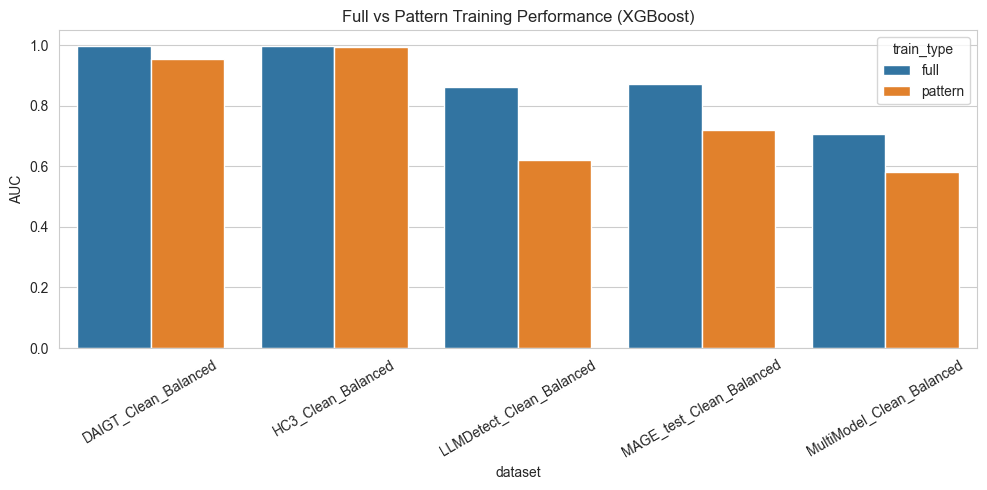

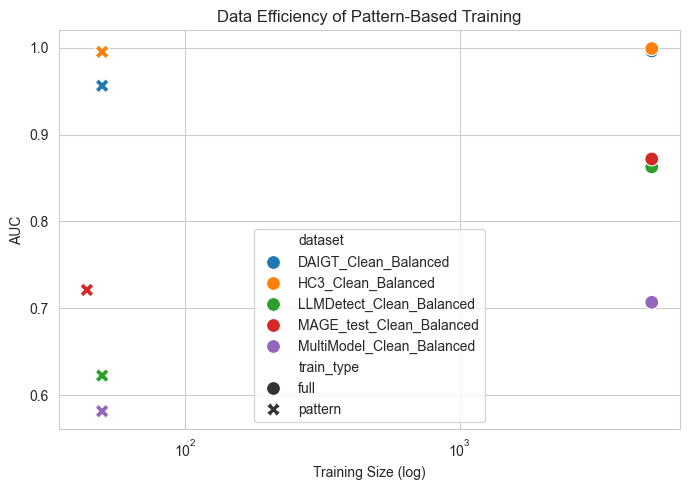

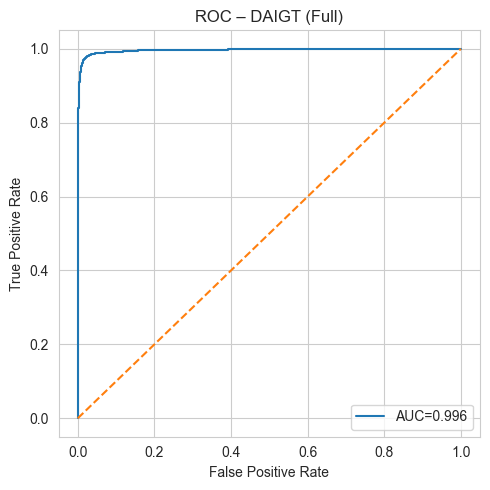

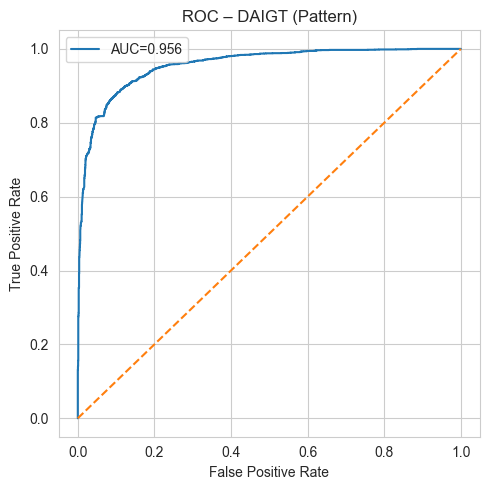

DAIGT_Clean_Balanced full 14
DAIGT_Clean_Balanced pattern 13
HC3_Clean_Balanced full 14
HC3_Clean_Balanced pattern 14
LLMDetect_Clean_Balanced full 14
LLMDetect_Clean_Balanced pattern 14
MAGE_test_Clean_Balanced full 14
MAGE_test_Clean_Balanced pattern 14
MultiModel_Clean_Balanced full 14
MultiModel_Clean_Balanced pattern 14


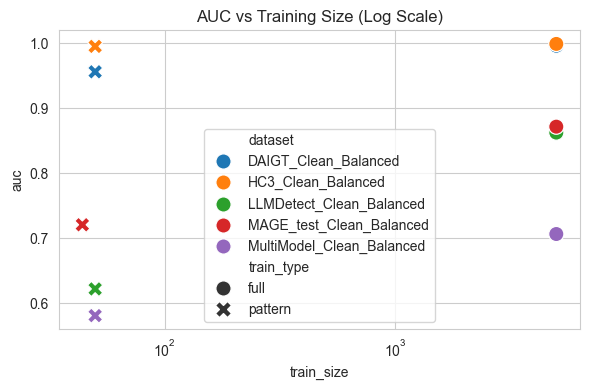

PermutationExplainer explainer: 5001it [08:31,  9.52it/s]                          
C:\Users\21063\AppData\Local\Temp\ipykernel_60896\2746640660.py:192: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


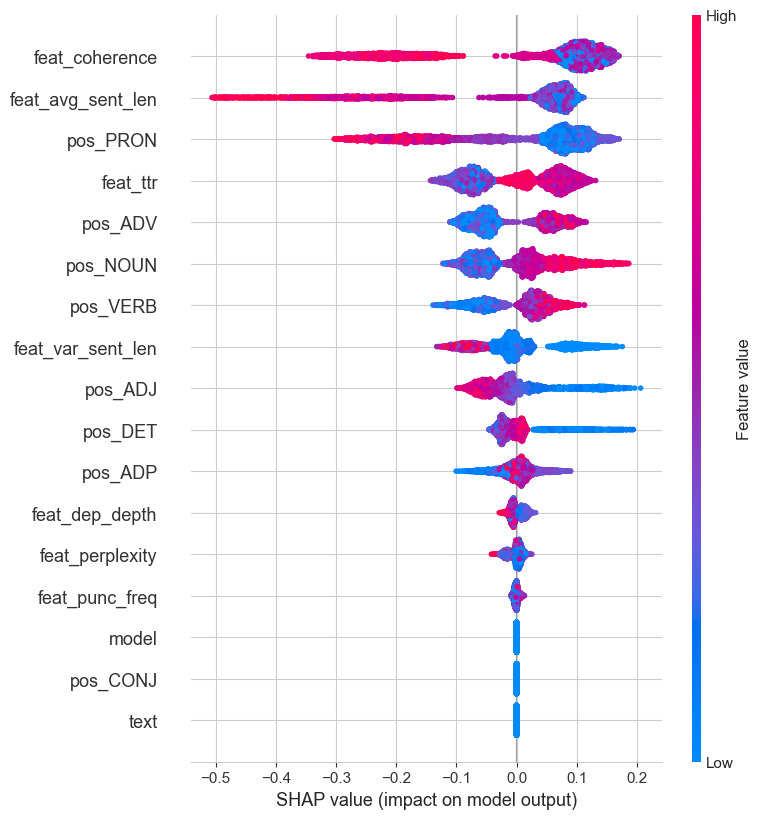

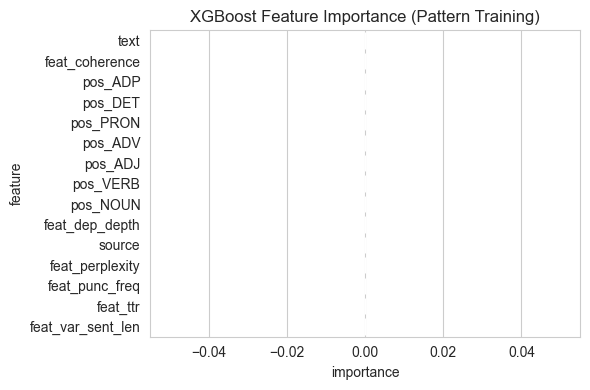

In [27]:
import xgboost as xgb
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve
import pandas as pd

def load_xy(csv_path):
    df = pd.read_csv(csv_path)

    # 你现在 CSV 里一定有 label
    if "label" not in df.columns:
        raise ValueError(f"{csv_path} has no label column")

    y = df["label"].astype(int)

    # 丢弃非特征列（非常关键）
    drop_cols = ["label"]
    if "cluster" in df.columns:
        drop_cols.append("cluster")

    X = df.drop(columns=drop_cols)

    # 确保全部是数值
    X = X.apply(pd.to_numeric, errors="coerce").fillna(0.0)

    return X, y

def train_eval_xgb(train_csv, test_csv):
    X_train, y_train = load_xy(train_csv)
    X_test, y_test = load_xy(test_csv)

    if len(set(y_train)) < 2:
        return None

    model = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="binary:logistic",
        eval_metric="auc",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        "model": model,
        "X_test": X_test,
        "y_test": y_test,
        "y_prob": y_prob,
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "auc": roc_auc_score(y_test, y_prob),
        "train_size": len(y_train)
    }
import pandas as pd
from pathlib import Path

FEATURE_DIR = Path(r"D:\Desktop\capstone\code\datasets\features")
PATTERN_DIR = FEATURE_DIR / "pattern_training_sets"
RESULT_DIR = Path(r"D:\Desktop\capstone\code\results")
RESULT_DIR.mkdir(exist_ok=True)

records = []
artifacts = {}

for train_file in FEATURE_DIR.glob("*_TRAIN_5k_Features_Clustered.csv"):
    dataset = train_file.stem.replace("_TRAIN_5k_Features_Clustered", "")
    test_file = FEATURE_DIR / f"{dataset}_TEST_5k_Features.csv"
    pattern_file = PATTERN_DIR / f"{train_file.stem}_PATTERN_TRAIN.csv"

    if not test_file.exists() or not pattern_file.exists():
        continue

    # Full
    full = train_eval_xgb(train_file, test_file)
    # Pattern
    pattern = train_eval_xgb(pattern_file, test_file)

    for name, res in [("full", full), ("pattern", pattern)]:
        records.append({
            "dataset": dataset,
            "train_type": name,
            "accuracy": res["accuracy"],
            "f1": res["f1"],
            "auc": res["auc"],
            "train_size": res["train_size"]
        })
        artifacts[(dataset, name)] = res

results_df = pd.DataFrame(records)
results_df.to_csv(RESULT_DIR / "xgb_results.csv", index=False)
print(results_df)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.barplot(
    data=results_df,
    x="dataset",
    y="auc",
    hue="train_type"
)
plt.ylabel("AUC")
plt.title("Full vs Pattern Training Performance (XGBoost)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(RESULT_DIR / "full_vs_pattern_auc_XGB.png", dpi=300)
plt.show()
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=results_df,
    x="train_size",
    y="auc",
    hue="dataset",
    style="train_type",
    s=100
)
plt.xscale("log")
plt.xlabel("Training Size (log)")
plt.ylabel("AUC")
plt.title("Data Efficiency of Pattern-Based Training")
plt.tight_layout()
plt.savefig(RESULT_DIR / "data_efficiency_XGB.png", dpi=300)
plt.show()
def plot_roc(res, title, out_name):
    fpr, tpr, _ = roc_curve(res["y_test"], res["y_prob"])
    plt.figure(figsize=(5,5))
    plt.plot(fpr, tpr, label=f"AUC={res['auc']:.3f}")
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_name, dpi=300)
    plt.show()

# 示例：DAIGT
plot_roc(
    artifacts[("DAIGT_Clean_Balanced", "full")],
    "ROC – DAIGT (Full)",
    RESULT_DIR / "roc_daigt_full_XGB.png"
)

plot_roc(
    artifacts[("DAIGT_Clean_Balanced", "pattern")],
    "ROC – DAIGT (Pattern)",
    RESULT_DIR / "roc_daigt_pattern_XGB.png"
)
def count_used_features(model):
    return sum(model.feature_importances_ > 0)

for (dataset, ttype), res in artifacts.items():
    print(dataset, ttype, count_used_features(res["model"]))
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.scatterplot(
    data=results_df,
    x="train_size",
    y="auc",
    hue="dataset",
    style="train_type",
    s=120
)
plt.xscale("log")
plt.title("AUC vs Training Size (Log Scale)")
plt.tight_layout()
plt.show()

import shap
import matplotlib.pyplot as plt

model = res["model"]
X_test = res["X_test"]

# 使用通用 Explainer（而不是 TreeExplainer）
explainer = shap.Explainer(
    model.predict_proba,
    X_test
)

shap_values = explainer(X_test)

shap.summary_plot(
    shap_values[..., 1],  # 正类（AI）的 SHAP
    X_test,
    show=False
)

plt.tight_layout()
plt.savefig(RESULT_DIR / "shap_summary_pattern_XGB.png", dpi=300)
plt.show()
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_xgb_feature_importance(
    model,
    X_reference,          # 用来拿 feature names
    title,
    out_path,
    top_k=15,
    importance_type="gain"  # 推荐 gain
):
    booster = model.get_booster()

    # 取 importance（gain / weight / cover）
    score_dict = booster.get_score(importance_type=importance_type)

    # feature 名
    feature_names = X_reference.columns.tolist()

    # 对齐所有特征（没被用到的 = 0）
    importance = []
    for i, f in enumerate(feature_names):
        key = f"f{i}"
        importance.append(score_dict.get(key, 0.0))

    df = (
        pd.DataFrame({
            "feature": feature_names,
            "importance": importance
        })
        .sort_values("importance", ascending=False)
        .head(top_k)
    )

    plt.figure(figsize=(6, 4))
    sns.barplot(data=df, x="importance", y="feature")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_path, dpi=300)
    plt.show()
res = artifacts[("DAIGT_Clean_Balanced", "pattern")]

plot_xgb_feature_importance(
    model=res["model"],
    X_reference=res["X_test"],
    title="XGBoost Feature Importance (Pattern Training)",
    out_path=RESULT_DIR / "xgb_feature_importance_pattern.png",
    top_k=15
)


   ---------------------------------------- 0.0/547.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/547.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/547.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/547.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/547.0 kB ? eta -:--:--
   ------------------- -------------------- 262.1/547.0 kB ? eta -:--:--
   ------------------- -------------------- 262.1/547.0 kB ? eta -:--:--
   ------------------- -------------------- 262.1/547.0 kB ? eta -:--:--
   -------------------------------------- 547.0/547.0 kB 371.9 kB/s eta 0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.7 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.7 MB ? eta -:--:--
 


[notice] A new release of pip is available: 25.0.1 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
!pip install interpret
! pip install xgboost shap seaborn scikit-learn matplotlib


     ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
     ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
     ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
     ----- ---------------------------------- 0.5/4.0 MB 2.8 MB/s eta 0:00:02
     --------------- ------------------------ 1.6/4.0 MB 4.0 MB/s eta 0:00:01
     ------------------------------- -------- 3.1/4.0 MB 5.0 MB/s eta 0:00:01
     ---------------------------------------- 4.0/4.0 MB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/16.6 MB ? eta -:--:--
   ---- ----------------------------------- 1.8/16.6 MB 9.1 MB/s eta 0:00:02
   ------ --------------------------------- 2.6/16.6 MB 10.1 MB/s eta 0:00:02
   --------- ------------------------------ 3.9/16.6 MB 6.9 MB/s eta 0:00:02
   ------------ --------------------------- 5.2/16.6 MB 6.2 MB/s eta 0:

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.2.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.37.2 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


                     dataset train_type  accuracy        f1       auc  \
0       DAIGT_Clean_Balanced       full    0.9726  0.972562  0.995256   
1       DAIGT_Clean_Balanced    pattern    0.8738  0.868951  0.948173   
2         HC3_Clean_Balanced       full    0.9904  0.990381  0.998551   
3         HC3_Clean_Balanced    pattern    0.9708  0.971215  0.994542   
4   LLMDetect_Clean_Balanced       full    0.7648  0.749894  0.828904   
5   LLMDetect_Clean_Balanced    pattern    0.5746  0.558439  0.605241   
6   MAGE_test_Clean_Balanced       full    0.7558  0.763875  0.829999   
7   MAGE_test_Clean_Balanced    pattern    0.6686  0.658983  0.707457   
8  MultiModel_Clean_Balanced       full    0.6536  0.626563  0.712526   
9  MultiModel_Clean_Balanced    pattern    0.5574  0.575484  0.587639   

   train_size  
0        5000  
1          50  
2        5000  
3          50  
4        5000  
5          50  
6        5000  
7          44  
8        5000  
9          50  


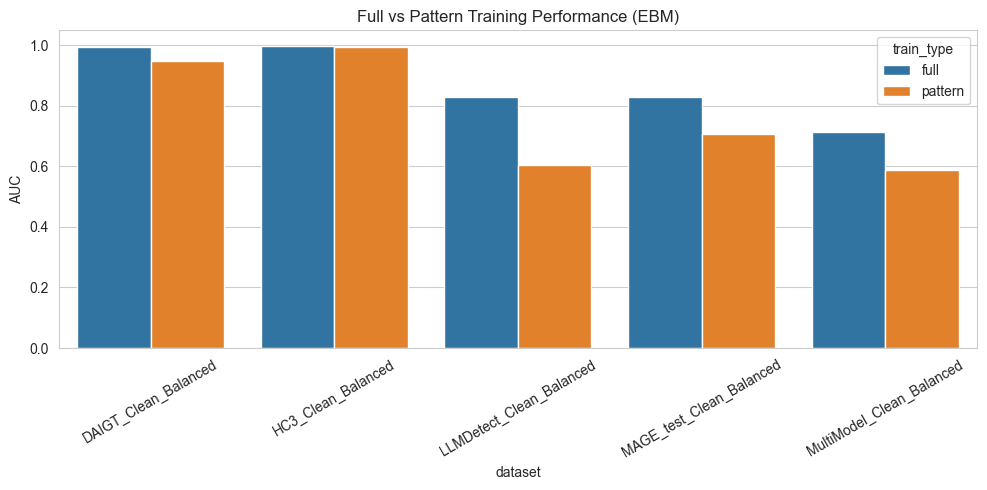

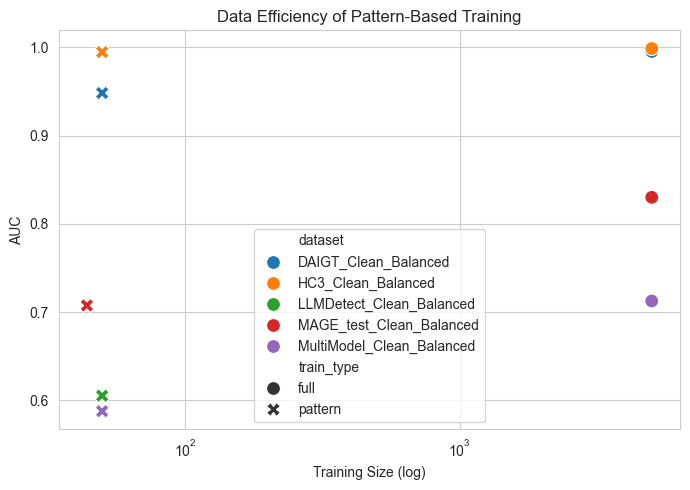

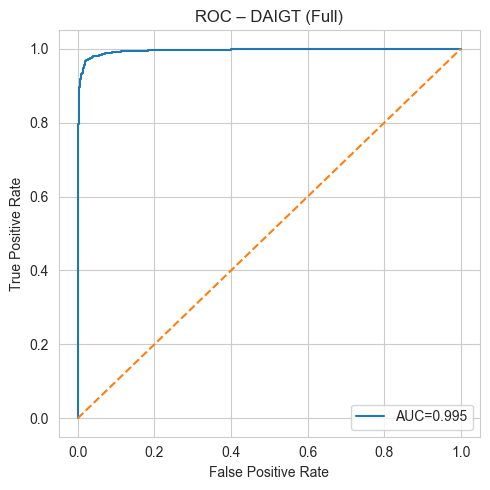

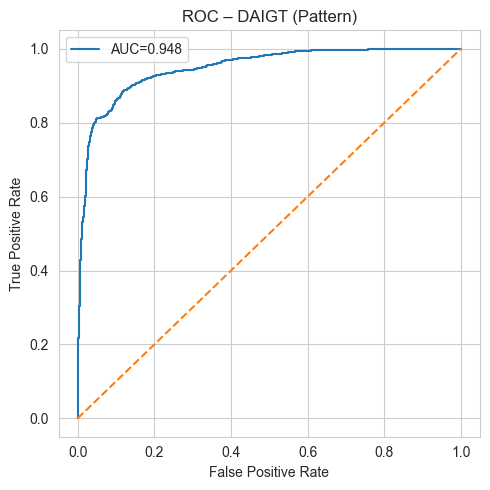

DAIGT_Clean_Balanced full 14
DAIGT_Clean_Balanced pattern 14
HC3_Clean_Balanced full 14
HC3_Clean_Balanced pattern 14
LLMDetect_Clean_Balanced full 14
LLMDetect_Clean_Balanced pattern 14
MAGE_test_Clean_Balanced full 14
MAGE_test_Clean_Balanced pattern 14
MultiModel_Clean_Balanced full 14
MultiModel_Clean_Balanced pattern 14


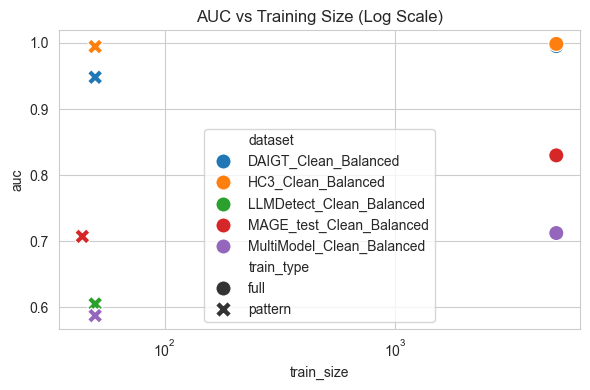

PermutationExplainer explainer: 5001it [04:27, 17.92it/s]                          
C:\Users\21063\AppData\Local\Temp\ipykernel_60896\3864650779.py:184: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


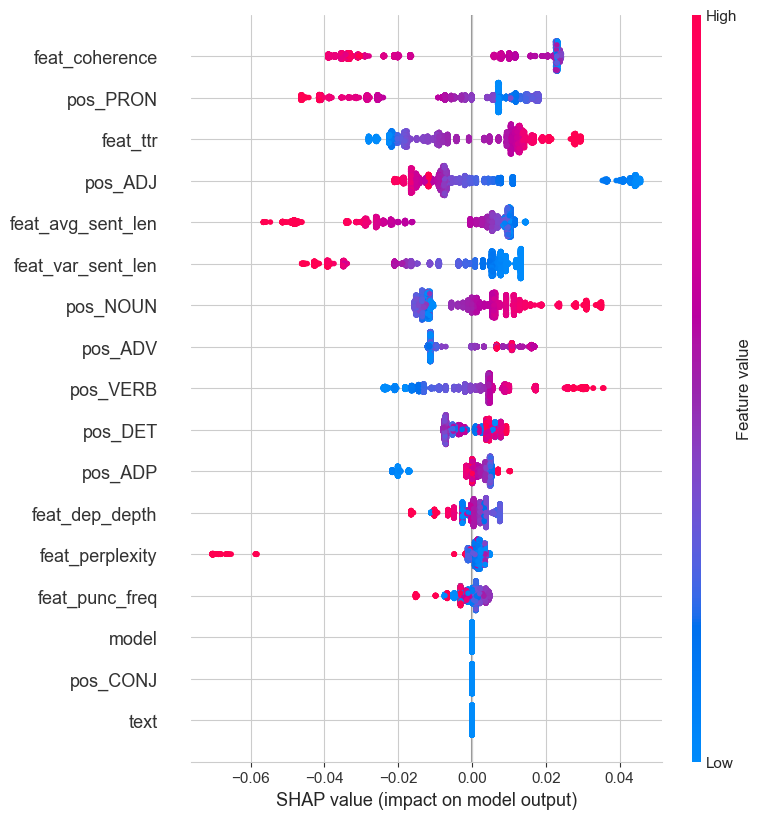

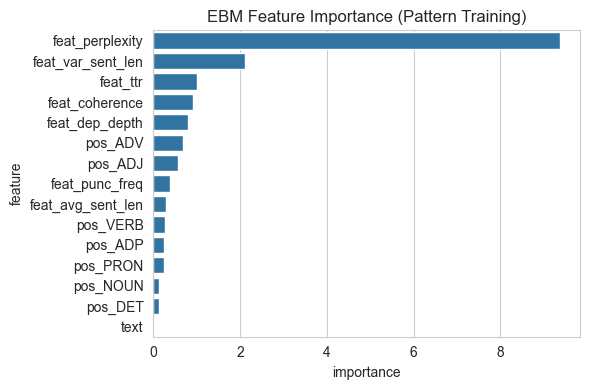

In [29]:
import xgboost as xgb
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve
import pandas as pd

from interpret.glassbox import ExplainableBoostingClassifier

def train_eval_ebm(train_csv, test_csv):
    X_train, y_train = load_xy(train_csv)
    X_test, y_test = load_xy(test_csv)

    model = ExplainableBoostingClassifier(
        interactions=0,
        random_state=42,
        n_jobs=1                     # ← add this
    )

    model.fit(X_train, y_train)

    prob = model.predict_proba(X_test)[:, 1]
    pred = (prob > 0.5).astype(int)

    return {
        "model": model,
        "accuracy": accuracy_score(y_test, pred),
        "f1": f1_score(y_test, pred),
        "auc": roc_auc_score(y_test, prob),
        "train_size": len(y_train),
        "X_test": X_test,
        "y_test": y_test,
        "y_prob": prob
    }

import pandas as pd
from pathlib import Path

FEATURE_DIR = Path(r"D:\Desktop\capstone\code\datasets\features")
PATTERN_DIR = FEATURE_DIR / "pattern_training_sets"
RESULT_DIR = Path(r"D:\Desktop\capstone\code\results")
RESULT_DIR.mkdir(exist_ok=True)

records = []
artifacts = {}

for train_file in FEATURE_DIR.glob("*_TRAIN_5k_Features_Clustered.csv"):
    dataset = train_file.stem.replace("_TRAIN_5k_Features_Clustered", "")
    test_file = FEATURE_DIR / f"{dataset}_TEST_5k_Features.csv"
    pattern_file = PATTERN_DIR / f"{train_file.stem}_PATTERN_TRAIN.csv"

    if not test_file.exists() or not pattern_file.exists():
        continue

    # Full
    full = train_eval_ebm(train_file, test_file)
    # Pattern
    pattern = train_eval_ebm(pattern_file, test_file)

    for name, res in [("full", full), ("pattern", pattern)]:
        records.append({
            "dataset": dataset,
            "train_type": name,
            "accuracy": res["accuracy"],
            "f1": res["f1"],
            "auc": res["auc"],
            "train_size": res["train_size"]
        })
        artifacts[(dataset, name)] = res

results_df = pd.DataFrame(records)
results_df.to_csv(RESULT_DIR / "gbm_results.csv", index=False)
print(results_df)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.barplot(
    data=results_df,
    x="dataset",
    y="auc",
    hue="train_type"
)
plt.ylabel("AUC")
plt.title("Full vs Pattern Training Performance (EBM)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(RESULT_DIR / "full_vs_pattern_auc_EBM.png", dpi=300)
plt.show()
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=results_df,
    x="train_size",
    y="auc",
    hue="dataset",
    style="train_type",
    s=100
)
plt.xscale("log")
plt.xlabel("Training Size (log)")
plt.ylabel("AUC")
plt.title("Data Efficiency of Pattern-Based Training")
plt.tight_layout()
plt.savefig(RESULT_DIR / "data_efficiency_EBM.png", dpi=300)
plt.show()
def plot_roc(res, title, out_name):
    fpr, tpr, _ = roc_curve(res["y_test"], res["y_prob"])
    plt.figure(figsize=(5,5))
    plt.plot(fpr, tpr, label=f"AUC={res['auc']:.3f}")
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_name, dpi=300)
    plt.show()

# 示例：DAIGT
plot_roc(
    artifacts[("DAIGT_Clean_Balanced", "full")],
    "ROC – DAIGT (Full)",
    RESULT_DIR / "roc_daigt_full_GBM.png"
)

plot_roc(
    artifacts[("DAIGT_Clean_Balanced", "pattern")],
    "ROC – DAIGT (Pattern)",
    RESULT_DIR / "roc_daigt_pattern_EBM.png"
)
import numpy as np
from sklearn.linear_model import LogisticRegression
from interpret.glassbox import ExplainableBoostingClassifier

def count_used_features(model, eps=1e-6):
    # Tree-based (XGBoost / RF)
    if hasattr(model, "feature_importances_"):
        return int(np.sum(model.feature_importances_ > eps))

    # Logistic Regression
    if isinstance(model, LogisticRegression):
        return int(np.sum(np.abs(model.coef_).ravel() > eps))

    # EBM (robust way)
    if isinstance(model, ExplainableBoostingClassifier):
        global_exp = model.explain_global()
        scores = np.array(global_exp.data()["scores"])
        return int(np.sum(scores > eps))

    raise TypeError(f"Unsupported model type: {type(model)}")


for (dataset, ttype), res in artifacts.items():
    print(dataset, ttype, count_used_features(res["model"]))
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.scatterplot(
    data=results_df,
    x="train_size",
    y="auc",
    hue="dataset",
    style="train_type",
    s=120
)
plt.xscale("log")
plt.title("AUC vs Training Size (Log Scale)")
plt.tight_layout()
plt.show()

import shap
import matplotlib.pyplot as plt

model = res["model"]
X_test = res["X_test"]

# 使用通用 Explainer（而不是 TreeExplainer）
explainer = shap.Explainer(
    model.predict_proba,
    X_test
)

shap_values = explainer(X_test)

shap.summary_plot(
    shap_values[..., 1],  # 正类（AI）的 SHAP
    X_test,
    show=False
)

plt.tight_layout()
plt.savefig(RESULT_DIR / "shap_summary_pattern_EBM.png", dpi=300)
plt.show()
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_ebm_feature_importance(model, title, out_path, top_k=15):
    global_exp = model.explain_global()
    names = global_exp.data()["names"]
    scores = global_exp.data()["scores"]

    df = (
        pd.DataFrame({
            "feature": names,
            "importance": np.abs(scores)
        })
        .sort_values("importance", ascending=False)
        .head(top_k)
    )

    plt.figure(figsize=(6, 4))
    sns.barplot(data=df, x="importance", y="feature")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_path, dpi=300)
    plt.show()
res = artifacts[("DAIGT_Clean_Balanced", "pattern")]

plot_ebm_feature_importance(
    res["model"],
    "EBM Feature Importance (Pattern Training)",
    RESULT_DIR / "ebm_feature_importance_pattern.png"
)

In [2]:
import torch
import numpy as np
import pandas as pd
from pathlib import Path
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()
    preds = (probs > 0.5).astype(int)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds),
        "auc": roc_auc_score(labels, probs)
    }
def train_eval_transformer(
    train_csv,
    test_csv,
    model_name,          # "bert-base-uncased" / "roberta-base"
    text_col="text",
    label_col="label",
    output_dir="./tmp",
    max_length=256,
    batch_size=16,
    epochs=3
):
    # 读数据
    train_df = pd.read_csv(train_csv)
    test_df = pd.read_csv(test_csv)

    train_ds = Dataset.from_pandas(train_df[[text_col, label_col]])
    test_ds = Dataset.from_pandas(test_df[[text_col, label_col]])

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    def tokenize(batch):
        return tokenizer(
            batch[text_col],
            padding="max_length",
            truncation=True,
            max_length=max_length
        )

    train_ds = train_ds.map(tokenize, batched=True)
    test_ds = test_ds.map(tokenize, batched=True)

    train_ds = train_ds.rename_column(label_col, "labels")
    test_ds = test_ds.rename_column(label_col, "labels")

    train_ds.set_format("torch")
    test_ds.set_format("torch")

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=2
    )

    args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="no",
        learning_rate=2e-5,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=epochs,
        weight_decay=0.01,
        logging_steps=50,
        report_to="none",
        fp16=True
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=test_ds,
        compute_metrics=compute_metrics
    )

    trainer.train()
    eval_res = trainer.evaluate()

    # 拿概率（为了 ROC）
    preds = trainer.predict(test_ds)
    probs = torch.softmax(torch.tensor(preds.predictions), dim=1)[:, 1].numpy()

    return {
        "model": model,
        "accuracy": eval_res["eval_accuracy"],
        "f1": eval_res["eval_f1"],
        "auc": eval_res["eval_auc"],
        "train_size": len(train_df),
        "y_test": test_df[label_col].values,
        "y_prob": probs
    }
records = []
artifacts = {}
FEATURE_DIR = Path(r"D:\Desktop\capstone\code\datasets\features")
PATTERN_DIR = FEATURE_DIR / "pattern_training_sets"
RESULT_DIR = Path(r"D:\Desktop\capstone\code\results")
RESULT_DIR.mkdir(exist_ok=True)

for train_file in FEATURE_DIR.glob("*_TRAIN_5k_Features_Clustered.csv"):
    dataset = train_file.stem.replace("_TRAIN_5k_Features_Clustered", "")
    test_file = FEATURE_DIR / f"{dataset}_TEST_5k_Features.csv"

    if not test_file.exists():
        continue

    # BERT
    bert_res = train_eval_transformer(
        train_file,
        test_file,
        model_name="bert-base-uncased",
        output_dir=f"./bert_{dataset}"
    )

    # RoBERTa
    roberta_res = train_eval_transformer(
        train_file,
        test_file,
        model_name="roberta-base",
        output_dir=f"./roberta_{dataset}"
    )

    for name, res in [("bert", bert_res), ("roberta", roberta_res)]:
        records.append({
            "dataset": dataset,
            "model": name,
            "accuracy": res["accuracy"],
            "f1": res["f1"],
            "auc": res["auc"],
            "train_size": res["train_size"]
        })
        artifacts[(dataset, name)] = res

results_df = pd.DataFrame(records)
results_df.to_csv(RESULT_DIR / "bert_roberta_results.csv", index=False)
print(results_df)

D:\Desktop\capstone\code\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 344.08it/s, Materializing param=bert.pooler.dense.weight]                               
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
clas

Epoch,Training Loss,Validation Loss,Accuracy,F1,Auc
1,0.117180,0.333620,0.924000,0.929157,0.998061
2,0.027436,0.052851,0.987600,0.987664,0.999006
3,0.014922,0.124297,0.975600,0.976069,0.998949


D:\Desktop\capstone\code\.venv\lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\21063\.cache\huggingface\hub\models--roberta-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Map: 100%|██████████| 5000/5000 [00:01<00:00, 4356.20 examples/s]


KeyboardInterrupt: 

In [1]:
import torch
import numpy as np
import pandas as pd
from pathlib import Path
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()
    preds = (probs > 0.5).astype(int)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds),
        "auc": roc_auc_score(labels, probs)
    }
def train_eval_transformer(
    train_csv,
    test_csv,
    model_name,          # "bert-base-uncased" / "roberta-base"
    text_col="text",
    label_col="label",
    output_dir="./tmp",
    max_length=256,
    batch_size=16,
    epochs=3
):
    # 读数据
    train_df = pd.read_csv(train_csv)
    test_df = pd.read_csv(test_csv)

    train_ds = Dataset.from_pandas(train_df[[text_col, label_col]])
    test_ds = Dataset.from_pandas(test_df[[text_col, label_col]])

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    def tokenize(batch):
        return tokenizer(
            batch[text_col],
            padding="max_length",
            truncation=True,
            max_length=max_length
        )

    train_ds = train_ds.map(tokenize, batched=True)
    test_ds = test_ds.map(tokenize, batched=True)

    train_ds = train_ds.rename_column(label_col, "labels")
    test_ds = test_ds.rename_column(label_col, "labels")

    train_ds.set_format("torch")
    test_ds.set_format("torch")

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=2
    )

    args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="no",
        learning_rate=2e-5,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=epochs,
        weight_decay=0.01,
        logging_steps=50,
        report_to="none",
        fp16=True
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=test_ds,
        compute_metrics=compute_metrics
    )

    trainer.train()
    eval_res = trainer.evaluate()

    # 拿概率（为了 ROC）
    preds = trainer.predict(test_ds)
    probs = torch.softmax(torch.tensor(preds.predictions), dim=1)[:, 1].numpy()

    return {
        "model": model,
        "accuracy": eval_res["eval_accuracy"],
        "f1": eval_res["eval_f1"],
        "auc": eval_res["eval_auc"],
        "train_size": len(train_df),
        "y_test": test_df[label_col].values,
        "y_prob": probs
    }
records = []
artifacts = {}
FEATURE_DIR = Path(r"D:\Desktop\capstone\code\datasets\features")
PATTERN_DIR = FEATURE_DIR / "pattern_training_sets"


for pattern_file in PATTERN_DIR.glob("*_PATTERN_TRAIN.csv"):
    dataset = pattern_file.stem.replace("_PATTERN_TRAIN", "")
    test_file = FEATURE_DIR / f"{dataset}_TEST_5k_Features.csv"

    if not test_file.exists():
        continue

    # BERT
    bert_res = train_eval_transformer(
    train_csv=pattern_file,   # ✅ 必须是 pattern_file
    test_csv=test_file,
    model_name="bert-base-uncased",
    output_dir=f"./bert_pattern_{dataset}",
    batch_size=4,             # 小样本必须减小
    epochs=10                 # 小样本必须多 epoch
    )

    # RoBERTa
    roberta_res = train_eval_transformer(
    train_csv=pattern_file,   # ✅ 必须是 pattern_file
    test_csv=test_file,
        model_name="roberta-base",
        output_dir=f"./roberta_{dataset}",
            batch_size=4,             # 小样本必须减小
    epochs=10
    )

    for name, res in [("bert", bert_res), ("roberta", roberta_res)]:
        records.append({
            "dataset": dataset,
            "model": name,
            "accuracy": res["accuracy"],
            "f1": res["f1"],
            "auc": res["auc"],
            "train_size": res["train_size"]
        })
        artifacts[(dataset, name)] = res
RESULT_DIR = Path(r"D:\Desktop\capstone\code\results")

results_df = pd.DataFrame(records)
results_df.to_csv(RESULT_DIR / "bert_roberta_results.csv", index=False)
print(results_df)

D:\Desktop\capstone\code\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 693.23it/s, Materializing param=bert.pooler.dense.weight]                               
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
clas

Epoch,Training Loss,Validation Loss,Accuracy,F1,Auc
1,No log,0.533189,0.890600,0.878848,0.982708
2,No log,0.552400,0.683600,0.759355,0.979650
3,No log,0.289489,0.953800,0.953456,0.987883
4,0.388055,0.263895,0.897600,0.906433,0.993408
5,0.388055,0.354299,0.822800,0.849012,0.992195
6,0.388055,0.132669,0.960600,0.961576,0.994873
7,0.388055,0.318312,0.851800,0.870432,0.992973
8,0.063762,0.328226,0.853200,0.871454,0.993565
9,0.063762,0.223204,0.898400,0.907232,0.994759
10,0.063762,0.225457,0.898200,0.907066,0.994744


Map: 100%|██████████| 5000/5000 [00:00<00:00, 5100.57 examples/s]
D:\Desktop\capstone\code\.venv\lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\21063\.cache\huggingface\hub\models--roberta-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 197/197 [00:00<00:00, 627.

Epoch,Training Loss,Validation Loss,Accuracy,F1,Auc
1,No log,0.685436,0.500000,0.000000,0.882836
2,No log,0.615704,0.801200,0.752982,0.983340
3,No log,0.182612,0.955600,0.957093,0.995352
4,0.493256,0.296328,0.905200,0.912932,0.991383
5,0.493256,0.906971,0.815600,0.843888,0.977190
6,0.493256,0.469927,0.909200,0.916421,0.989859
7,0.493256,0.448008,0.917200,0.923220,0.993742
8,0.005949,0.704847,0.876800,0.890000,0.990745
9,0.005949,0.753199,0.870800,0.885258,0.989761
10,0.005949,0.752142,0.871600,0.885887,0.989443


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 505.39it/s, Materializing param=bert.pooler.dense.weight]                               
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those pa

...

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 530.27it/s, Materializing param=bert.pooler.dense.weight]                               
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those pa

Epoch,Training Loss,Validation Loss,Accuracy,F1,Auc
1,No log,0.689211,0.536000,0.633607,0.563305
2,No log,0.679456,0.567800,0.552495,0.599221
3,No log,0.672490,0.574800,0.593810,0.621951
4,0.607843,0.674790,0.582200,0.600650,0.630751
5,0.607843,0.694301,0.571000,0.619478,0.631188
6,0.607843,0.702464,0.583400,0.620237,0.636128
7,0.607843,0.732547,0.563800,0.625708,0.633768
8,0.269099,0.740959,0.597000,0.597724,0.642843
9,0.269099,0.763287,0.596200,0.597729,0.642645
10,0.269099,0.768334,0.595000,0.603019,0.643677


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 233.08it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

Epoch,Training Loss,Validation Loss,Accuracy,F1,Auc
1,No log,0.692912,0.508600,0.620189,0.539048
2,No log,0.689225,0.574600,0.541891,0.593266
3,No log,0.690719,0.507800,0.637395,0.603752
4,0.669217,0.695172,0.517200,0.633131,0.602307
5,0.669217,0.697965,0.559000,0.620939,0.606395
6,0.669217,0.735258,0.552400,0.629470,0.610311
7,0.669217,0.805324,0.558600,0.628138,0.607697
8,0.372171,0.787066,0.583400,0.593244,0.614617
9,0.372171,0.868605,0.579200,0.625489,0.619311
10,0.372171,0.842097,0.590000,0.601012,0.623989


NameError: name 'RESULT_DIR' is not defined

In [2]:
RESULT_DIR = Path(r"D:\Desktop\capstone\code\results")

results_df = pd.DataFrame(records)
results_df.to_csv(RESULT_DIR / "bert_roberta_results.csv", index=False)
print(results_df)

                     dataset    model  accuracy        f1       auc  \
0       DAIGT_Clean_Balanced     bert    0.8982  0.907066  0.994744   
1       DAIGT_Clean_Balanced  roberta    0.8716  0.885887  0.989443   
2         HC3_Clean_Balanced     bert    0.8596  0.876885  0.994535   
3         HC3_Clean_Balanced  roberta    0.9080  0.915565  0.994940   
4   LLMDetect_Clean_Balanced     bert    0.5782  0.537804  0.605330   
5   LLMDetect_Clean_Balanced  roberta    0.5566  0.481404  0.572915   
6   MAGE_test_Clean_Balanced     bert    0.5422  0.541374  0.570378   
7   MAGE_test_Clean_Balanced  roberta    0.5794  0.593309  0.621867   
8  MultiModel_Clean_Balanced     bert    0.5950  0.603019  0.643677   
9  MultiModel_Clean_Balanced  roberta    0.5900  0.601012  0.623989   

   train_size  
0          50  
1          50  
2          50  
3          50  
4          50  
5          50  
6          44  
7          44  
8          50  
9          50  


In [1]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else None)


CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [3]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121


Looking in indexes: https://download.pytorch.org/whl/cu121
     ---------------------------------------- 0.0/2.4 GB ? eta -:--:--
     ---------------------------------------- 0.0/2.4 GB ? eta -:--:--
     ---------------------------------------- 0.0/2.4 GB ? eta -:--:--
     ---------------------------------------- 0.0/2.4 GB 3.1 MB/s eta 0:12:59
     ---------------------------------------- 0.0/2.4 GB 5.6 MB/s eta 0:07:18
     ---------------------------------------- 0.0/2.4 GB 9.2 MB/s eta 0:04:26
     ---------------------------------------- 0.0/2.4 GB 12.9 MB/s eta 0:03:10
     ---------------------------------------- 0.0/2.4 GB 12.8 MB/s eta 0:03:11
     ---------------------------------------- 0.0/2.4 GB 15.2 MB/s eta 0:02:40
     ---------------------------------------- 0.0/2.4 GB 16.8 MB/s eta 0:02:25
      --------------------------------------- 0.0/2.4 GB 17.7 MB/s eta 0:02:17
      --------------------------------------- 0.0/2.4 GB 18.3 MB/s eta 0:02:13
      --------------


[notice] A new release of pip is available: 25.0.1 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
!pip install -U accelerate
!pip install -U transformers[torch]



[notice] A new release of pip is available: 25.0.1 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached hf_xet-1.2.0-cp37-abi3-win_amd64.whl.metadata (5.0 kB)
   ---------------------------------------- 0.0/536.7 kB ? eta -:--:--
   ---------------------------------------- 0.0/536.7 kB ? eta -:--:--
   ---------------------------------------- 536.7/536.7 kB 1.8 MB/s eta 0:00:00
Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl (2.7 MB)
   ---------------------------------------- 0.0/113.7 MB ? eta -:--:--
   ---------------------------------------- 0.8/113.7 MB 4.8 MB/s eta 0:00:24
   ---------------------------------------- 1.0/113.7 MB 5.0 MB/s eta 0:00:23
   ---------------------------------------- 1.0/113.7 MB 5.0 MB/s eta 0:00:23
    --------------------------------------- 2.1/113.7 MB 2.6 MB/s eta 0:00:44
   - -------------------------------------- 3.1/113.7 MB 3.1 MB/s eta 0:00:36
   - -------------------------------------- 4.5/113.7 MB 3.5 MB/s eta 0:00:31
   - -------------------------

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.1.0+cu118 requires torch==2.1.0+cu118, but you have torch 2.10.0 which is incompatible.
torchvision 0.16.0+cu118 requires torch==2.1.0+cu118, but you have torch 2.10.0 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


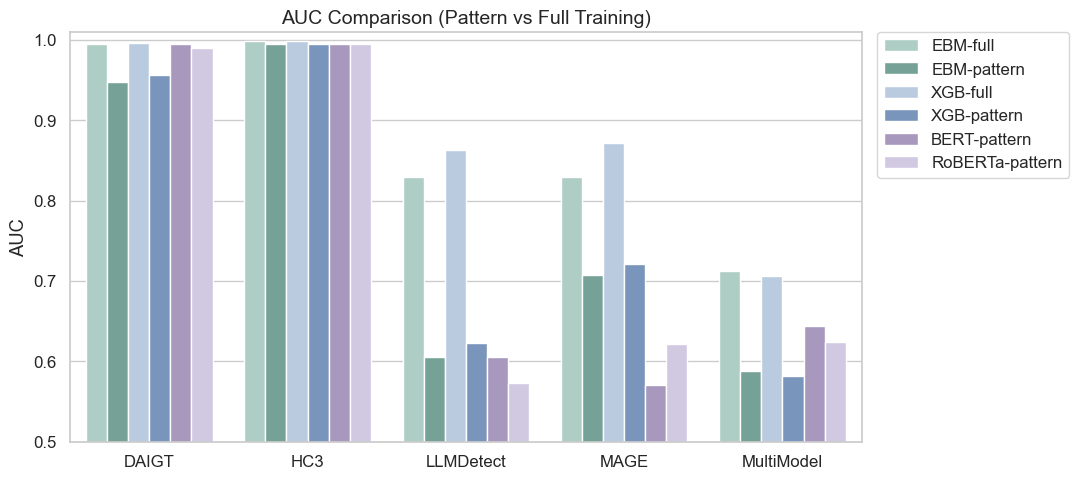

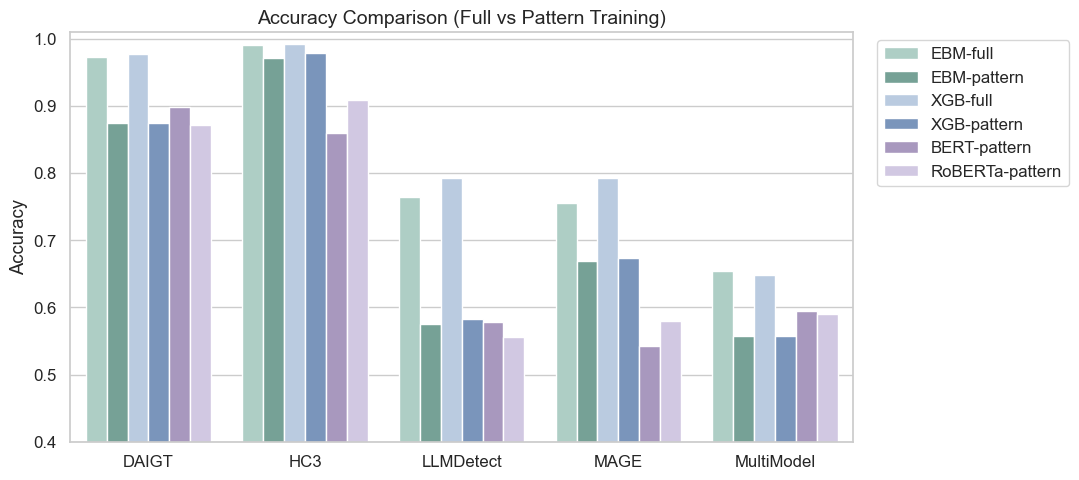

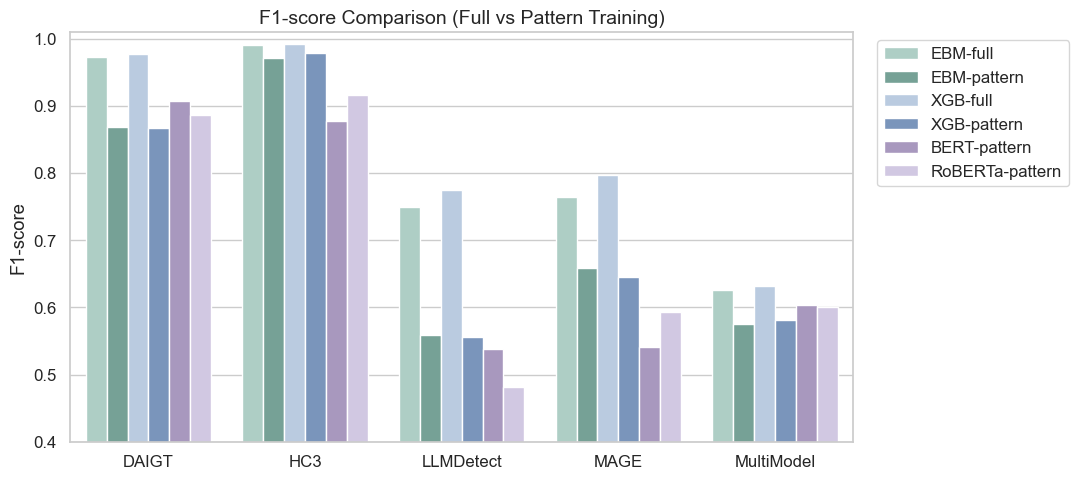

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ========= 1. 手动构造 DataFrame（最稳妥，避免读错文件） =========
data = [
    # ----- EBM -----
    ("DAIGT", "EBM-full", 0.995256),
    ("DAIGT", "EBM-pattern", 0.948173),
    ("HC3", "EBM-full", 0.998551),
    ("HC3", "EBM-pattern", 0.994542),
    ("LLMDetect", "EBM-full", 0.828904),
    ("LLMDetect", "EBM-pattern", 0.605241),
    ("MAGE", "EBM-full", 0.829999),
    ("MAGE", "EBM-pattern", 0.707457),
    ("MultiModel", "EBM-full", 0.712526),
    ("MultiModel", "EBM-pattern", 0.587639),

    # ----- XGBoost -----
    ("DAIGT", "XGB-full", 0.996352),
    ("DAIGT", "XGB-pattern", 0.956271),
    ("HC3", "XGB-full", 0.999138),
    ("HC3", "XGB-pattern", 0.995359),
    ("LLMDetect", "XGB-full", 0.862785),
    ("LLMDetect", "XGB-pattern", 0.622391),
    ("MAGE", "XGB-full", 0.871910),
    ("MAGE", "XGB-pattern", 0.721051),
    ("MultiModel", "XGB-full", 0.706826),
    ("MultiModel", "XGB-pattern", 0.581360),

    # ----- Transformer (pattern only) -----
    ("DAIGT", "BERT-pattern", 0.994744),
    ("HC3", "BERT-pattern", 0.994535),
    ("LLMDetect", "BERT-pattern", 0.605330),
    ("MAGE", "BERT-pattern", 0.570378),
    ("MultiModel", "BERT-pattern", 0.643677),

    ("DAIGT", "RoBERTa-pattern", 0.989443),
    ("HC3", "RoBERTa-pattern", 0.994940),
    ("LLMDetect", "RoBERTa-pattern", 0.572915),
    ("MAGE", "RoBERTa-pattern", 0.621867),
    ("MultiModel", "RoBERTa-pattern", 0.623989),
]

df = pd.DataFrame(data, columns=["Dataset", "Model", "AUC"])
palette = [
    "#A9D3C7",
    "#6FA89A",  # deeper muted teal（EBM-full）
      # soft teal（EBM-pattern）
        "#B4CAE6",
    "#6F93C6",  # deeper muted blue（XGB-full）
  # soft blue（XGB-pattern）
    "#A792C4",  # deeper lavender（BERT-pattern）
    "#D0C4E6",  # soft lavender（RoBERTa-pattern）
]

# ========= 2. 画图 =========
plt.figure(figsize=(11, 5))
sns.set(style="whitegrid", font_scale=1.1)

ax = sns.barplot(
    data=df,
    x="Dataset",
    y="AUC",
    hue="Model",
    palette=palette
)


plt.ylim(0.5, 1.01)
plt.ylabel("AUC")
plt.xlabel("")
plt.title("AUC Comparison (Pattern vs Full Training)", fontsize=14)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()
plt.savefig("overall_auc_comparison.png", dpi=300)
plt.show()
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = [
    # ===== EBM =====
    ("DAIGT", "EBM-full", 0.9726, 0.972562),
    ("DAIGT", "EBM-pattern", 0.8738, 0.868951),
    ("HC3", "EBM-full", 0.9904, 0.990381),
    ("HC3", "EBM-pattern", 0.9708, 0.971215),
    ("LLMDetect", "EBM-full", 0.7648, 0.749894),
    ("LLMDetect", "EBM-pattern", 0.5746, 0.558439),
    ("MAGE", "EBM-full", 0.7558, 0.763875),
    ("MAGE", "EBM-pattern", 0.6686, 0.658983),
    ("MultiModel", "EBM-full", 0.6536, 0.626563),
    ("MultiModel", "EBM-pattern", 0.5574, 0.575484),

    # ===== XGBoost =====
    ("DAIGT", "XGB-full", 0.9766, 0.976539),
    ("DAIGT", "XGB-pattern", 0.8750, 0.867444),
    ("HC3", "XGB-full", 0.9918, 0.991782),
    ("HC3", "XGB-pattern", 0.9784, 0.978622),
    ("LLMDetect", "XGB-full", 0.7926, 0.774614),
    ("LLMDetect", "XGB-pattern", 0.5826, 0.555485),
    ("MAGE", "XGB-full", 0.7926, 0.797580),
    ("MAGE", "XGB-pattern", 0.6734, 0.645077),
    ("MultiModel", "XGB-full", 0.6486, 0.631579),
    ("MultiModel", "XGB-pattern", 0.5568, 0.581413),

    # ===== Transformer (pattern only) =====
    ("DAIGT", "BERT-pattern", 0.8982, 0.907066),
    ("HC3", "BERT-pattern", 0.8596, 0.876885),
    ("LLMDetect", "BERT-pattern", 0.5782, 0.537804),
    ("MAGE", "BERT-pattern", 0.5422, 0.541374),
    ("MultiModel", "BERT-pattern", 0.5950, 0.603019),

    ("DAIGT", "RoBERTa-pattern", 0.8716, 0.885887),
    ("HC3", "RoBERTa-pattern", 0.9080, 0.915565),
    ("LLMDetect", "RoBERTa-pattern", 0.5566, 0.481404),
    ("MAGE", "RoBERTa-pattern", 0.5794, 0.593309),
    ("MultiModel", "RoBERTa-pattern", 0.5900, 0.601012),
]

df = pd.DataFrame(
    data,
    columns=["Dataset", "Model", "Accuracy", "F1"]
)
plt.figure(figsize=(11, 5))
sns.set(style="whitegrid", font_scale=1.1)

sns.barplot(
    data=df,
    x="Dataset",
    y="Accuracy",
    hue="Model",
    palette=palette
)


plt.ylim(0.4, 1.01)
plt.ylabel("Accuracy")
plt.xlabel("")
plt.title("Accuracy Comparison (Full vs Pattern Training)", fontsize=14)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.savefig("overall_accuracy_comparison.png", dpi=300)
plt.show()
plt.figure(figsize=(11, 5))
sns.set(style="whitegrid", font_scale=1.1)

sns.barplot(
    data=df,
    x="Dataset",
    y="F1",
    hue="Model",
    palette=palette
)


plt.ylim(0.4, 1.01)
plt.ylabel("F1-score")
plt.xlabel("")
plt.title("F1-score Comparison (Full vs Pattern Training)", fontsize=14)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.savefig("overall_f1_comparison.png", dpi=300)
plt.show()


Total samples: 25000. Datasets: ['MultiModel', 'HC3', 'DAIGT', 'LLMDetect', 'MAGE']
1. Multi-dataset radar charts saved.
2. Divergence boxplots saved.
3. AI deviation heatmap saved.
4. Global density plots saved.

All specialized analysis plots saved to: D:\Desktop\capstone\code\datasets\features\analysis_results


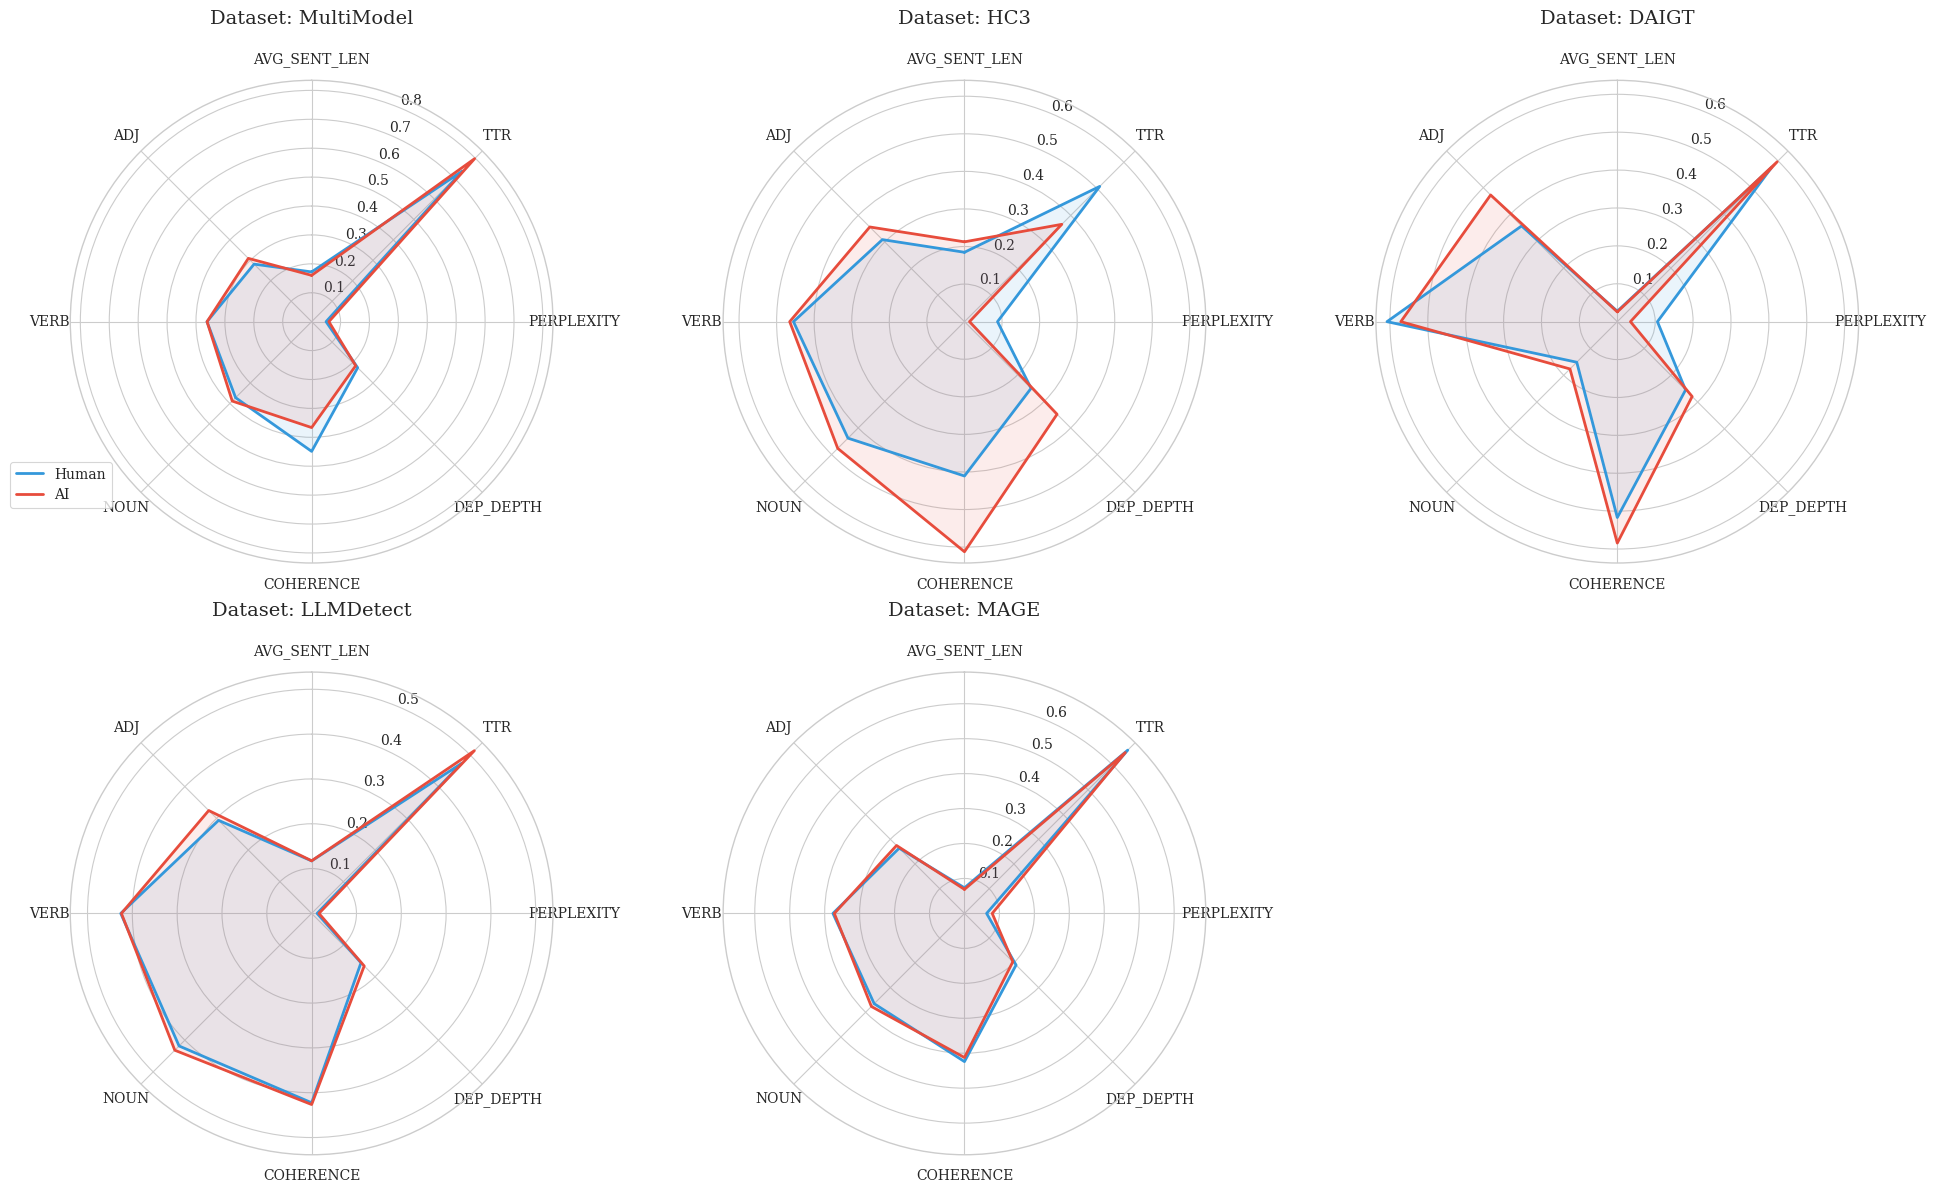

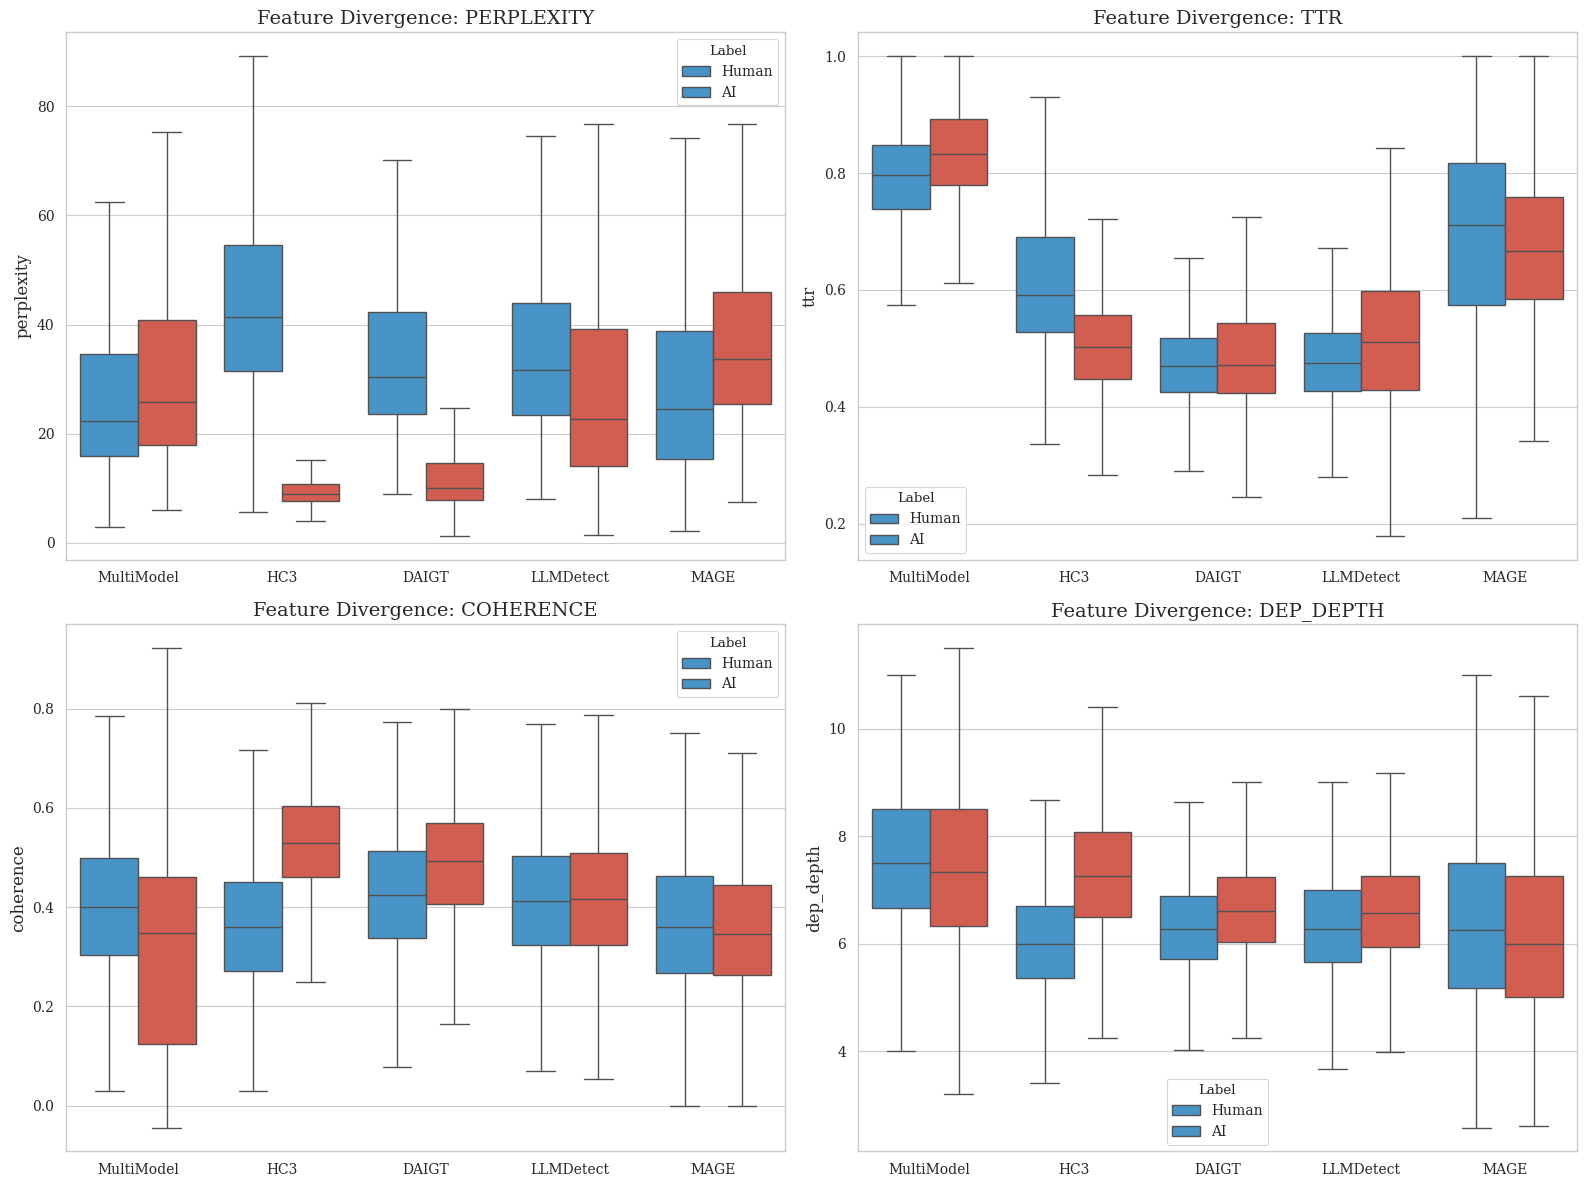

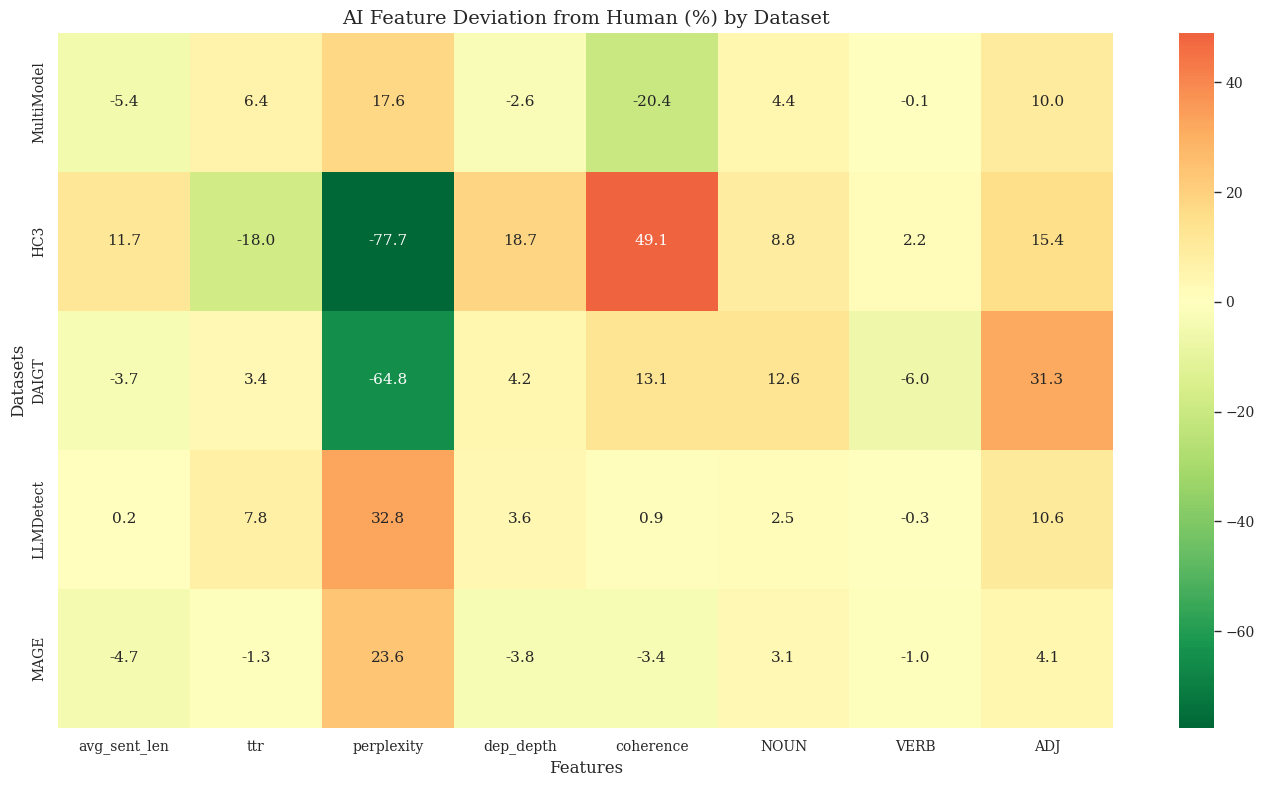

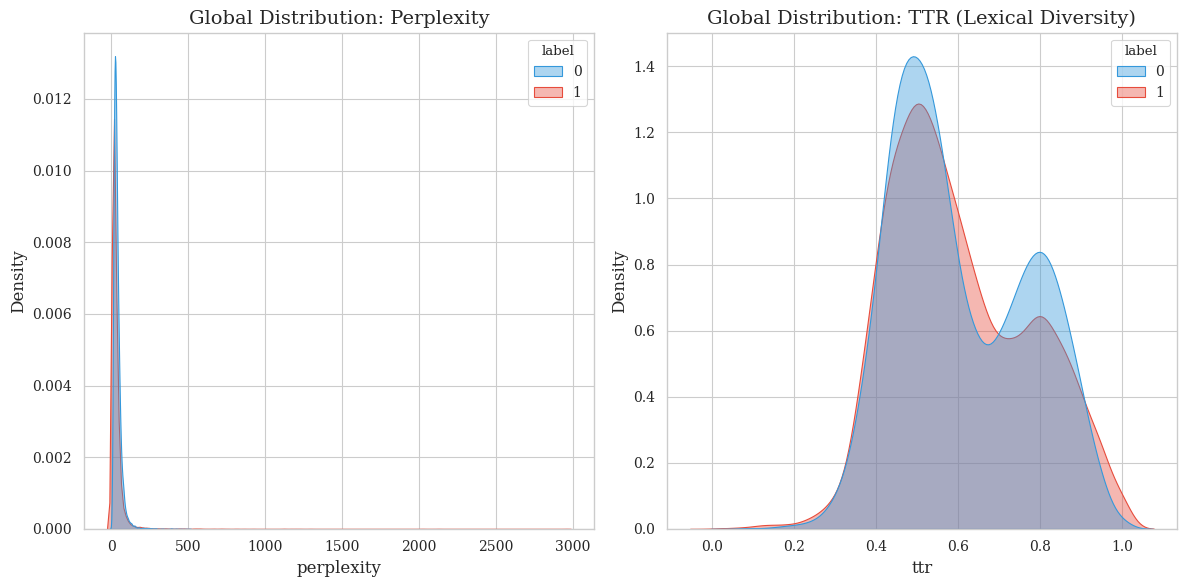

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler

# --- Academic Plotting Style Configuration ---
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'savefig.dpi': 300
})

def run_feature_eda():
    FEATURE_DIR = Path(r"D:\Desktop\capstone\code\datasets\features")
    RESULTS_DIR = FEATURE_DIR / "analysis_results"
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)

    # 1. Load and merge datasets
    files = {
        "MultiModel": "MultiModel_Clustered_Patterns.csv",
        "HC3": "HC3_Clean_Balanced_Features_Sampled.csv",
        "DAIGT": "DAIGT_Clean_Balanced_Features_Sampled.csv",
        "LLMDetect": "LLMDetect_Clean_Balanced_Features_Sampled.csv",
        "MAGE": "MAGE_test_Clean_Balanced_Features_Sampled.csv"
    }

    all_dfs = []
    for name, fname in files.items():
        p = FEATURE_DIR / fname
        if p.exists():
            df = pd.read_csv(p)
            df['Dataset'] = name
            # Normalize column names for consistency
            df.columns = [c.replace('feat_', '').replace('pos_', '') for c in df.columns]
            all_dfs.append(df)
    
    if not all_dfs:
        print("Error: No feature files found in the specified directory.")
        return

    full_df = pd.concat(all_dfs, ignore_index=True)
    
    # Selected core features for visualization
    core_features = ['avg_sent_len', 'ttr', 'perplexity', 'dep_depth', 'coherence', 'NOUN', 'VERB', 'ADJ']
    
    print(f"Total samples: {len(full_df)}. Datasets: {list(files.keys())}")

    # ========================================================
    # Plot 1: Multi-Dataset Radar Charts (AI vs Human Fingerprint)
    # Goal: Compare the "shape" of writing for each dataset
    # ========================================================
    num_datasets = len(all_dfs)
    fig = plt.figure(figsize=(20, 12))
    angles = np.linspace(0, 2 * np.pi, len(core_features), endpoint=False).tolist()
    angles += angles[:1]
    labels = [f.upper() for f in core_features]

    scaler = MinMaxScaler()

    for i, name in enumerate(files.keys()):
        df_ds = full_df[full_df['Dataset'] == name]
        if df_ds.empty: continue
        
        # Scale features within the dataset for fair comparison
        ds_norm = pd.DataFrame(scaler.fit_transform(df_ds[core_features]), columns=core_features)
        ds_norm['label'] = df_ds['label'].values

        ax = fig.add_subplot(2, 3, i+1, polar=True)
        
        # Human average line
        hu_vals = ds_norm[ds_norm['label'] == 0][core_features].mean().tolist()
        hu_vals += hu_vals[:1]
        ax.plot(angles, hu_vals, color='#3498db', linewidth=2, label="Human")
        ax.fill(angles, hu_vals, color='#3498db', alpha=0.1)

        # AI average line
        ai_vals = ds_norm[ds_norm['label'] == 1][core_features].mean().tolist()
        ai_vals += ai_vals[:1]
        ax.plot(angles, ai_vals, color='#e74c3c', linewidth=2, label="AI")
        ax.fill(angles, ai_vals, color='#e74c3c', alpha=0.1)

        ax.set_theta_offset(np.pi / 2)
        ax.set_theta_direction(-1)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(labels)
        ax.set_title(f"Dataset: {name}", size=14, y=1.1)
        if i == 0: ax.legend(loc='lower right', bbox_to_anchor=(0.1, 0.1))

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "multi_dataset_radar_comparison.png")
    print("1. Multi-dataset radar charts saved.")

    # ========================================================
    # Plot 2: Boxplot Analysis of Divergent Features
    # Goal: Highlight features where AI and Human are significantly different
    # ========================================================
    # We choose Perplexity and TTR as they usually show maximum divergence
    divergent_feats = ['perplexity', 'ttr', 'coherence', 'dep_depth']
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()

    for i, feat in enumerate(divergent_feats):
        sns.boxplot(data=full_df, x='Dataset', y=feat, hue='label', 
                    palette={0: "#3498db", 1: "#e74c3c"}, ax=axes[i], showfliers=False)
        axes[i].set_title(f'Feature Divergence: {feat.upper()}')
        axes[i].set_xlabel('')
        axes[i].legend(title='Label', labels=['Human', 'AI'])

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "feature_divergence_boxplots.png")
    print("2. Divergence boxplots saved.")

    # ========================================================
    # Plot 3: Deviation Heatmap (Quantifying the Gap)
    # Goal: Show how much AI deviates from Human in % for each dataset
    # ========================================================
    heatmap_data = []
    for name in files.keys():
        ds = full_df[full_df['Dataset'] == name]
        hu_m = ds[ds['label'] == 0][core_features].mean()
        ai_m = ds[ds['label'] == 1][core_features].mean()
        # % Deviation = (AI - Human) / Human * 100
        dev = ((ai_m - hu_m) / hu_m) * 100
        dev.name = name
        heatmap_data.append(dev)
    
    dev_df = pd.concat(heatmap_data, axis=1).T

    plt.figure(figsize=(14, 8))
    sns.heatmap(dev_df, annot=True, cmap='RdYlGn_r', center=0, fmt=".1f")
    plt.title("AI Feature Deviation from Human (%) by Dataset")
    plt.xlabel("Features")
    plt.ylabel("Datasets")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "ai_deviation_heatmap.png")
    print("3. AI deviation heatmap saved.")

    # ========================================================
    # Plot 4: Combined Density Plot (Global Linguistic Fingerprint)
    # Goal: Show overlapping and non-overlapping areas across all data
    # ========================================================
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    sns.kdeplot(data=full_df, x='perplexity', hue='label', fill=True, palette={0: "#3498db", 1: "#e74c3c"}, alpha=0.4)
    plt.title("Global Distribution: Perplexity")
    
    plt.subplot(1, 2, 2)
    sns.kdeplot(data=full_df, x='ttr', hue='label', fill=True, palette={0: "#3498db", 1: "#e74c3c"}, alpha=0.4)
    plt.title("Global Distribution: TTR (Lexical Diversity)")
    
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "global_density_comparison.png")
    print("4. Global density plots saved.")

    print(f"\nAll specialized analysis plots saved to: {RESULTS_DIR}")

if __name__ == "__main__":
    run_feature_eda()